In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os
import zipfile
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)
print("Seed setup completed successfully!")

Random seed: 42
Seed setup completed successfully!


In [6]:
from google.colab import files
import zipfile
import os
import shutil

# Upload ZIP file
uploaded = files.upload()

# Get uploaded ZIP filename
zip_path = list(uploaded.keys())[0]

# Extraction folder
extract_path = "/content/image_dataset"

# Remove old folder if it exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("ZIP file:", zip_path)
print("Extracted to:", extract_path)

Saving New_dataset.zip to New_dataset.zip
Dataset extracted successfully!
ZIP file: New_dataset.zip
Extracted to: /content/image_dataset


In [7]:
import os

print("Dataset structure:\n")

for root, dirs, files in os.walk("/content/image_dataset"):
    level = root.replace("/content/image_dataset", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    {file}")

Dataset structure:

image_dataset/
    New_dataset/
        test/
            Fake/
                sri_lanka_fake_0445.jpg
                sri_lanka_fake_0490.jpg
                sri_lanka_fake_0474.jpg
                sri_lanka_fake_0486.jpg
                7f3cb7f42700fc8e729e6d6d584fafe5-en.jpeg
            Real/
                images (12).jpg
                image_fb7feb54cd.jpg
                images (15).jpg
                images (40).jpg
                image_fcb8e6f088.jpg
        validation/
            Fake/
                sri_lanka_fake_0379.jpg
                sri_lanka_fake_0408.jpg
                sri_lanka_fake_0375.jpg
                sri_lanka_fake_0394.jpg
                sri_lanka_fake_0385.jpg
            Real/
                images (49).jpg
                images 1_large_small.jpg
                jaffna-university0_27_01_2025-1000x600-1.jpg
                WEB (4)-855122.jpg
                pgim-e1448265462583.jpg
        train/
            Fake/
             

In [8]:
# Correct dataset path
base_dir = "/content/image_dataset/New_dataset"

print("Dataset path:")
print(base_dir)

print("\nFolders found:")

for folder in ["train", "validation", "test"]:
    path = os.path.join(base_dir, folder)
    print(folder, "→", os.path.exists(path))

Dataset path:
/content/image_dataset/New_dataset

Folders found:
train → True
validation → True
test → True


In [9]:
for split in ["train", "validation", "test"]:

    print(f"\n{split.upper()}")
    print("-" * 30)

    for class_name in ["Fake", "Real"]:

        folder = os.path.join(
            base_dir,
            split,
            class_name
        )

        image_files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ]

        print(f"{class_name}: {len(image_files)} images")


TRAIN
------------------------------
Fake: 345 images
Real: 348 images

VALIDATION
------------------------------
Fake: 75 images
Real: 75 images

TEST
------------------------------
Fake: 75 images
Real: 74 images


In [10]:
image_paths = []
labels = []

# Combine train + validation for 5-fold cross-validation
for split in ["train", "validation"]:

    split_dir = os.path.join(base_dir, split)

    for class_name in ["Fake", "Real"]:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        for file_name in os.listdir(class_dir):

            if file_name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):

                image_paths.append(
                    os.path.join(
                        class_dir,
                        file_name
                    )
                )

                # Fake = 0, Real = 1
                if class_name == "Fake":
                    labels.append(0)
                else:
                    labels.append(1)

# Create DataFrame
cv_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("Total images for 5-fold CV:", len(cv_df))

print("\nClass distribution:")
print(cv_df["label"].value_counts())

print("\nLabel meaning:")
print("0 = Fake")
print("1 = Real")

Total images for 5-fold CV: 843

Class distribution:
label
1    423
0    420
Name: count, dtype: int64

Label meaning:
0 = Fake
1 = Real


In [11]:
from sklearn.model_selection import StratifiedKFold

# Create 5-fold stratified cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

X = cv_df["filepath"].values
y = cv_df["label"].values

folds = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    train_df = cv_df.iloc[train_idx].reset_index(drop=True)
    val_df = cv_df.iloc[val_idx].reset_index(drop=True)

    folds.append((train_df, val_df))

    print(f"\n========== FOLD {fold} ==========")

    print("Training images  :", len(train_df))
    print("Validation images:", len(val_df))

    print("\nTraining distribution:")
    print(train_df["label"].value_counts().sort_index())

    print("\nValidation distribution:")
    print(val_df["label"].value_counts().sort_index())


========== FOLD 1 ==========
Training images  : 674
Validation images: 169

Training distribution:
label
0    336
1    338
Name: count, dtype: int64

Validation distribution:
label
0    84
1    85
Name: count, dtype: int64

========== FOLD 2 ==========
Training images  : 674
Validation images: 169

Training distribution:
label
0    336
1    338
Name: count, dtype: int64

Validation distribution:
label
0    84
1    85
Name: count, dtype: int64

========== FOLD 3 ==========
Training images  : 674
Validation images: 169

Training distribution:
label
0    336
1    338
Name: count, dtype: int64

Validation distribution:
label
0    84
1    85
Name: count, dtype: int64

========== FOLD 4 ==========
Training images  : 675
Validation images: 168

Training distribution:
label
0    336
1    339
Name: count, dtype: int64

Validation distribution:
label
0    84
1    84
Name: count, dtype: int64

========== FOLD 5 ==========
Training images  : 675
Validation images: 168

Training distribution:
labe

In [12]:
# Image size required for ResNet50
IMG_SIZE = (224, 224)

# Batch size
BATCH_SIZE = 16

# TensorFlow performance setting
AUTOTUNE = tf.data.AUTOTUNE

print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)

Image size : (224, 224)
Batch size : 16


In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [14]:
def load_image(filepath, label, training=False):

    # Read image file
    image = tf.io.read_file(filepath)

    # Decode image as RGB
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Allow variable original image size
    image.set_shape([None, None, 3])

    # Resize to ResNet50 input size
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    # Apply augmentation ONLY for training
    if training:
        image = data_augmentation(image)

    # ResNet50 ImageNet preprocessing
    image = preprocess_input(image)

    return image, label


print("Image loading function created successfully!")

Image loading function created successfully!


In [15]:
def create_dataset(df, training=False):

    # Get image paths and labels
    paths = df["filepath"].values
    labels = df["label"].values

    # Create TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    # Shuffle only training data
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED
        )

    # Load and preprocess images
    dataset = dataset.map(
        lambda x, y: load_image(
            x,
            y,
            training
        ),
        num_parallel_calls=AUTOTUNE
    )

    # Create batches
    dataset = dataset.batch(
        BATCH_SIZE
    )

    # Improve performance
    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


print("Dataset creation function ready!")

Dataset creation function ready!


In [16]:
def build_resnet50():

    # Load pretrained ResNet50
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze ResNet50 initially
    base_model.trainable = False

    # Input
    inputs = keras.Input(
        shape=(224, 224, 3)
    )

    # ResNet50 feature extraction
    x = base_model(
        inputs,
        training=False
    )

    # Convert feature maps to a single vector
    x = layers.GlobalAveragePooling2D()(x)

    # Batch normalization
    x = layers.BatchNormalization()(x)

    # Regularization
    x = layers.Dropout(0.4)(x)

    # Fully connected layer
    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    # More regularization
    x = layers.Dropout(0.3)(x)

    # Binary classification
    # 0 = Fake
    # 1 = Real
    outputs = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    # Create model
    model = keras.Model(
        inputs=inputs,
        outputs=outputs
    )

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-4
        ),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )

    return model


print("ResNet50 model function created successfully!")

ResNet50 model function created successfully!


In [17]:
model = build_resnet50()

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [18]:
# Select Fold 1
fold_number = 1

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 1 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["label"].value_counts().sort_index())

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 1 datasets created successfully!")

========== FOLD 1 ==========
Training images  : 674
Validation images: 169

Training distribution:
label
0    336
1    338
Name: count, dtype: int64

Validation distribution:
label
0    84
1    85
Name: count, dtype: int64

Fold 1 datasets created successfully!


In [19]:
callbacks = [

    # Stop training if validation loss does not improve
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss stops improving
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [20]:
from PIL import Image

corrupted_files = []

for filepath in cv_df["filepath"]:

    try:
        with Image.open(filepath) as img:
            img.verify()

    except Exception as e:
        corrupted_files.append((filepath, str(e)))

print("====================================")
print("CORRUPTED IMAGE CHECK")
print("====================================")

print("Total images checked :", len(cv_df))
print("Corrupted images     :", len(corrupted_files))

if corrupted_files:
    print("\nCorrupted files:")

    for filepath, error in corrupted_files:
        print("\n", filepath)
        print("Error:", error)
else:
    print("\nNo corrupted images found.")

CORRUPTED IMAGE CHECK
Total images checked : 843
Corrupted images     : 0

No corrupted images found.


In [21]:
from PIL import Image

clean_dir = "/content/clean_cv_dataset"

# Remove old clean dataset
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

os.makedirs(clean_dir, exist_ok=True)

clean_paths = []
clean_labels = []

failed_files = []

for index, row in cv_df.iterrows():

    source_path = row["filepath"]
    label = row["label"]

    try:
        # Open image using PIL
        img = Image.open(source_path)

        # Convert everything to standard RGB
        img = img.convert("RGB")

        # Create new filename
        new_filename = f"image_{index:05d}.jpg"
        new_path = os.path.join(
            clean_dir,
            new_filename
        )

        # Save as standard JPEG
        img.save(
            new_path,
            "JPEG",
            quality=95
        )

        clean_paths.append(new_path)
        clean_labels.append(label)

    except Exception as e:
        failed_files.append(
            (source_path, str(e))
        )

# Create clean DataFrame
clean_cv_df = pd.DataFrame({
    "filepath": clean_paths,
    "label": clean_labels
})

print("====================================")
print("CLEAN DATASET")
print("====================================")

print("Original CV images :", len(cv_df))
print("Clean CV images    :", len(clean_cv_df))
print("Failed images      :", len(failed_files))

print("\nClass distribution:")
print(clean_cv_df["label"].value_counts().sort_index())

if failed_files:
    print("\nFailed files:")
    for filepath, error in failed_files:
        print(filepath)
        print(error)

CLEAN DATASET
Original CV images : 843
Clean CV images    : 814
Failed images      : 29

Class distribution:
label
0    420
1    394
Name: count, dtype: int64

Failed files:
/content/image_dataset/New_dataset/train/Real/Dematagoda Shooting 1-855546_650x250.jpg
image file is truncated (32 bytes not processed)
/content/image_dataset/New_dataset/train/Real/ICC Women's Champions Trophy 2027 Sri Lanka 1-853668_650x250.jpg
image file is truncated (6 bytes not processed)
/content/image_dataset/New_dataset/train/Real/14 - 11 - 2025-855589_650x250.jpg
image file is truncated (50 bytes not processed)
/content/image_dataset/New_dataset/train/Real/Arrest Handcuff-837864-855148_650x250.jpg
image file is truncated (10 bytes not processed)
/content/image_dataset/New_dataset/train/Real/donald-855218_650x250.jpg
image file is truncated (5 bytes not processed)
/content/image_dataset/New_dataset/train/Real/Easter Attacks Kochchikade 1-810712_850x460-855249_650x250.jpg
image file is truncated (29 bytes no

In [22]:
from PIL import Image

image_paths = []
labels = []

failed_files = []

# Use train + validation
for split in ["train", "validation"]:

    split_dir = os.path.join(
        base_dir,
        split
    )

    for class_name in ["Fake", "Real"]:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        for file_name in os.listdir(class_dir):

            file_path = os.path.join(
                class_dir,
                file_name
            )

            # Try to open every file as an image
            try:
                with Image.open(file_path) as img:
                    img.verify()

                image_paths.append(file_path)

                if class_name == "Fake":
                    labels.append(0)
                else:
                    labels.append(1)

            except Exception as e:
                failed_files.append(
                    (file_path, str(e))
                )

# Create clean DataFrame
cv_df = pd.DataFrame({
    "filepath": image_paths,
    "label": labels
})

print("======================================")
print("FINAL CLEAN CV DATASET")
print("======================================")

print("Valid images :", len(cv_df))
print("Failed images:", len(failed_files))

print("\nClass distribution:")
print(
    cv_df["label"]
    .value_counts()
    .sort_index()
)

print("\nLabel meaning:")
print("0 = Fake")
print("1 = Real")

print("\nFailed images removed:", len(failed_files))

FINAL CLEAN CV DATASET
Valid images : 850
Failed images: 0

Class distribution:
label
0    425
1    425
Name: count, dtype: int64

Label meaning:
0 = Fake
1 = Real

Failed images removed: 0


In [23]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

X = cv_df["filepath"].values
y = cv_df["label"].values

folds = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    train_df = cv_df.iloc[train_idx].reset_index(drop=True)
    val_df = cv_df.iloc[val_idx].reset_index(drop=True)

    folds.append((train_df, val_df))

    print(f"\n========== FOLD {fold} ==========")
    print("Training images  :", len(train_df))
    print("Validation images:", len(val_df))

    print("\nTraining:")
    print(
        train_df["label"]
        .value_counts()
        .sort_index()
    )

    print("\nValidation:")
    print(
        val_df["label"]
        .value_counts()
        .sort_index()
    )


========== FOLD 1 ==========
Training images  : 680
Validation images: 170

Training:
label
0    340
1    340
Name: count, dtype: int64

Validation:
label
0    85
1    85
Name: count, dtype: int64

========== FOLD 2 ==========
Training images  : 680
Validation images: 170

Training:
label
0    340
1    340
Name: count, dtype: int64

Validation:
label
0    85
1    85
Name: count, dtype: int64

========== FOLD 3 ==========
Training images  : 680
Validation images: 170

Training:
label
0    340
1    340
Name: count, dtype: int64

Validation:
label
0    85
1    85
Name: count, dtype: int64

========== FOLD 4 ==========
Training images  : 680
Validation images: 170

Training:
label
0    340
1    340
Name: count, dtype: int64

Validation:
label
0    85
1    85
Name: count, dtype: int64

========== FOLD 5 ==========
Training images  : 680
Validation images: 170

Training:
label
0    340
1    340
Name: count, dtype: int64

Validation:
label
0    85
1    85
Name: count, dtype: int64


In [24]:
# Select Fold 1
fold_number = 1

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 1 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining class distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 1 TensorFlow datasets created successfully!")

========== FOLD 1 ==========
Training images  : 680
Validation images: 170

Training class distribution:
label
0    340
1    340
Name: count, dtype: int64

Validation class distribution:
label
0    85
1    85
Name: count, dtype: int64

Fold 1 TensorFlow datasets created successfully!


In [25]:
from PIL import Image

safe_dir = "/content/safe_cv_dataset"

# Remove old folder
if os.path.exists(safe_dir):
    shutil.rmtree(safe_dir)

os.makedirs(safe_dir, exist_ok=True)

safe_paths = []
safe_labels = []
failed_files = []

for index, row in cv_df.iterrows():

    source_path = row["filepath"]
    label = row["label"]

    try:
        # Open with PIL
        img = Image.open(source_path)

        # Fully load image into memory
        img.load()

        # Convert to standard RGB
        img = img.convert("RGB")

        # Create safe JPEG filename
        new_filename = f"safe_image_{index:05d}.jpg"

        new_path = os.path.join(
            safe_dir,
            new_filename
        )

        # Save as a completely new JPEG
        img.save(
            new_path,
            format="JPEG",
            quality=95
        )

        safe_paths.append(new_path)
        safe_labels.append(label)

    except Exception as e:
        failed_files.append(
            (source_path, str(e))
        )

# Create safe DataFrame
safe_cv_df = pd.DataFrame({
    "filepath": safe_paths,
    "label": safe_labels
})

print("======================================")
print("TENSORFLOW-SAFE DATASET")
print("======================================")

print("Original images :", len(cv_df))
print("Safe images     :", len(safe_cv_df))
print("Failed images   :", len(failed_files))

print("\nClass distribution:")
print(
    safe_cv_df["label"]
    .value_counts()
    .sort_index()
)

TENSORFLOW-SAFE DATASET
Original images : 850
Safe images     : 821
Failed images   : 29

Class distribution:
label
0    425
1    396
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import StratifiedKFold

# Use the TensorFlow-safe dataset
cv_df = safe_cv_df.copy()

# 5-fold stratified cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

X = cv_df["filepath"].values
y = cv_df["label"].values

folds = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    train_df = cv_df.iloc[train_idx].reset_index(drop=True)
    val_df = cv_df.iloc[val_idx].reset_index(drop=True)

    folds.append((train_df, val_df))

    print(f"\n========== FOLD {fold} ==========")
    print("Training images  :", len(train_df))
    print("Validation images:", len(val_df))

    print("\nTraining distribution:")
    print(
        train_df["label"]
        .value_counts()
        .sort_index()
    )

    print("\nValidation distribution:")
    print(
        val_df["label"]
        .value_counts()
        .sort_index()
    )


========== FOLD 1 ==========
Training images  : 656
Validation images: 165

Training distribution:
label
0    340
1    316
Name: count, dtype: int64

Validation distribution:
label
0    85
1    80
Name: count, dtype: int64

========== FOLD 2 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

========== FOLD 3 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

========== FOLD 4 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

========== FOLD 5 ==========
Training images  : 657
Validation images: 164

Training distribution:
labe

In [27]:
# Select Fold 1
fold_number = 1

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 1 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 1 TensorFlow datasets created!")

========== FOLD 1 ==========
Training images  : 656
Validation images: 165

Training distribution:
label
0    340
1    316
Name: count, dtype: int64

Validation distribution:
label
0    85
1    80
Name: count, dtype: int64

Fold 1 TensorFlow datasets created!


In [28]:
# Test every batch in Fold 1

print("Testing Fold 1 training dataset...")

train_batch_count = 0

for images, labels in train_ds:
    train_batch_count += 1

print("Training batches loaded successfully:", train_batch_count)


print("\nTesting Fold 1 validation dataset...")

val_batch_count = 0

for images, labels in val_ds:
    val_batch_count += 1

print("Validation batches loaded successfully:", val_batch_count)


print("\n================================")
print("FOLD 1 DATASET TEST PASSED")
print("================================")

Testing Fold 1 training dataset...
Training batches loaded successfully: 41

Testing Fold 1 validation dataset...
Validation batches loaded successfully: 11

FOLD 1 DATASET TEST PASSED


In [29]:
# Create a fresh ResNet50 model for Fold 1
model = build_resnet50()

# Train Fold 1
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 30s 413ms/step - accuracy: 0.7241 - loss: 0.6316 - precision: 0.6619 - recall: 0.8734 - val_accuracy: 0.7879 - val_loss: 0.4584 - val_precision: 0.6991 - val_recall: 0.9875 - learning_rate: 1.0000e-04
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step - accuracy: 0.8262 - loss: 0.3980 - precision: 0.7902 - recall: 0.8703 - val_accuracy: 0.9273 - val_loss: 0.3065 - val_precision: 0.8864 - val_recall: 0.9750 - learning_rate: 1.0000e-04
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 258ms/step - accuracy: 0.8689 - loss: 0.3389 - precision: 0.8485 - recall: 0.8861 - val_accuracy: 0.9333 - val_loss: 0.2494 - val_precision: 0.9157 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 0.8659 - loss: 0.3169 - precision: 0.8608 - recall: 0.8608 - val_accuracy: 0.9333 - val_loss: 0.2346 - val_precision: 0.9157 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 23

In [30]:
# Evaluate Fold 1
fold1_results = model.evaluate(
    val_ds,
    verbose=1
)

fold1_loss = fold1_results[0]
fold1_accuracy = fold1_results[1]
fold1_precision = fold1_results[2]
fold1_recall = fold1_results[3]

# Calculate F1-score
fold1_f1 = (
    2 * fold1_precision * fold1_recall
    / (fold1_precision + fold1_recall + 1e-8)
)

print("\n================================")
print("FOLD 1 RESULTS")
print("================================")

print(f"Loss      : {fold1_loss:.4f}")
print(f"Accuracy  : {fold1_accuracy:.4f}")
print(f"Precision : {fold1_precision:.4f}")
print(f"Recall    : {fold1_recall:.4f}")
print(f"F1 Score  : {fold1_f1:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.9515 - loss: 0.1858 - precision: 0.9390 - recall: 0.9625

FOLD 1 RESULTS
Loss      : 0.1858
Accuracy  : 0.9515
Precision : 0.9390
Recall    : 0.9625
F1 Score  : 0.9506


In [31]:
# Select Fold 2
fold_number = 2

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 2 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 2 TensorFlow datasets created!")

========== FOLD 2 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

Fold 2 TensorFlow datasets created!


In [32]:
# Test Fold 2 training dataset
print("Testing Fold 2 training dataset...")

train_batch_count = 0

for images, labels in train_ds:
    train_batch_count += 1

print(
    "Training batches loaded successfully:",
    train_batch_count
)


# Test Fold 2 validation dataset
print("\nTesting Fold 2 validation dataset...")

val_batch_count = 0

for images, labels in val_ds:
    val_batch_count += 1

print(
    "Validation batches loaded successfully:",
    val_batch_count
)


print("\n================================")
print("FOLD 2 DATASET TEST PASSED")
print("================================")

Testing Fold 2 training dataset...
Training batches loaded successfully: 42

Testing Fold 2 validation dataset...
Validation batches loaded successfully: 11

FOLD 2 DATASET TEST PASSED


In [33]:
# Create a completely fresh ResNet50 model for Fold 2
model = build_resnet50()

# Train Fold 2
history_fold2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 33s 514ms/step - accuracy: 0.6393 - loss: 0.8003 - precision: 0.6980 - recall: 0.4448 - val_accuracy: 0.8171 - val_loss: 0.3853 - val_precision: 0.8356 - val_recall: 0.7722 - learning_rate: 1.0000e-04
Epoch 2/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7738 - loss: 0.5241 - precision: 0.8250 - recall: 0.6345
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.7823 - loss: 0.5263 - precision: 0.8537 - recall: 0.6625 - val_accuracy: 0.8963 - val_loss: 0.2856 - val_precision: 0.8974 - val_recall: 0.8861 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 230ms/step - accuracy: 0.8311 - loss: 0.4309 - precision: 0.8872 - recall: 0.7445 - val_accuracy: 0.9024 - val_loss: 0.2705 - val_precision: 0.9200 - val_recall: 0.8734 - learning_rate: 2.0000e-05
Epoch 4/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8001 - loss: 0.4473 - precis

In [34]:
# Evaluate Fold 2
fold2_results = model.evaluate(
    val_ds,
    verbose=1
)

fold2_loss = fold2_results[0]
fold2_accuracy = fold2_results[1]
fold2_precision = fold2_results[2]
fold2_recall = fold2_results[3]

# Calculate F1-score
fold2_f1 = (
    2 * fold2_precision * fold2_recall
    / (fold2_precision + fold2_recall + 1e-8)
)

print("\n================================")
print("FOLD 2 RESULTS")
print("================================")

print(f"Loss      : {fold2_loss:.4f}")
print(f"Accuracy  : {fold2_accuracy:.4f}")
print(f"Precision : {fold2_precision:.4f}")
print(f"Recall    : {fold2_recall:.4f}")
print(f"F1 Score  : {fold2_f1:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8171 - loss: 0.3853 - precision: 0.8356 - recall: 0.7722

FOLD 2 RESULTS
Loss      : 0.3853
Accuracy  : 0.8171
Precision : 0.8356
Recall    : 0.7722
F1 Score  : 0.8026


In [35]:
# Select Fold 3
fold_number = 3

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 3 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 3 TensorFlow datasets created!")

========== FOLD 3 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

Fold 3 TensorFlow datasets created!


In [36]:
# Test Fold 3 training dataset
print("Testing Fold 3 training dataset...")

train_batch_count = 0

for images, labels in train_ds:
    train_batch_count += 1

print(
    "Training batches loaded successfully:",
    train_batch_count
)


# Test Fold 3 validation dataset
print("\nTesting Fold 3 validation dataset...")

val_batch_count = 0

for images, labels in val_ds:
    val_batch_count += 1

print(
    "Validation batches loaded successfully:",
    val_batch_count
)


print("\n================================")
print("FOLD 3 DATASET TEST PASSED")
print("================================")

Testing Fold 3 training dataset...
Training batches loaded successfully: 42

Testing Fold 3 validation dataset...
Validation batches loaded successfully: 11

FOLD 3 DATASET TEST PASSED


In [37]:
# Create a completely fresh ResNet50 model for Fold 3
model = build_resnet50()

# Train Fold 3
history_fold3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 494ms/step - accuracy: 0.6347 - loss: 0.8071 - precision: 0.6711 - recall: 0.4763 - val_accuracy: 0.8354 - val_loss: 0.4224 - val_precision: 0.9062 - val_recall: 0.7342 - learning_rate: 1.0000e-04
Epoch 2/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.7858 - loss: 0.5155 - precision: 0.8396 - recall: 0.6522
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - accuracy: 0.7702 - loss: 0.5583 - precision: 0.8430 - recall: 0.6435 - val_accuracy: 0.8841 - val_loss: 0.3175 - val_precision: 0.9286 - val_recall: 0.8228 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 253ms/step - accuracy: 0.8082 - loss: 0.4535 - precision: 0.8375 - recall: 0.7476 - val_accuracy: 0.8841 - val_loss: 0.3053 - val_precision: 0.9286 - val_recall: 0.8228 - learning_rate: 2.0000e-05
Epoch 4/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.8385 - loss: 0.3980 - precis

In [38]:
# Evaluate Fold 3
fold3_results = model.evaluate(
    val_ds,
    verbose=1
)

fold3_loss = fold3_results[0]
fold3_accuracy = fold3_results[1]
fold3_precision = fold3_results[2]
fold3_recall = fold3_results[3]

# Calculate F1-score
fold3_f1 = (
    2 * fold3_precision * fold3_recall
    / (fold3_precision + fold3_recall + 1e-8)
)

print("\n================================")
print("FOLD 3 RESULTS")
print("================================")

print(f"Loss      : {fold3_loss:.4f}")
print(f"Accuracy  : {fold3_accuracy:.4f}")
print(f"Precision : {fold3_precision:.4f}")
print(f"Recall    : {fold3_recall:.4f}")
print(f"F1 Score  : {fold3_f1:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8354 - loss: 0.4224 - precision: 0.9062 - recall: 0.7342

FOLD 3 RESULTS
Loss      : 0.4224
Accuracy  : 0.8354
Precision : 0.9062
Recall    : 0.7342
F1 Score  : 0.8112


In [39]:
# Select Fold 4
fold_number = 4

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 4 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 4 TensorFlow datasets created!")

========== FOLD 4 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

Fold 4 TensorFlow datasets created!


In [40]:
# Test Fold 4 training dataset
print("Testing Fold 4 training dataset...")

train_batch_count = 0

for images, labels in train_ds:
    train_batch_count += 1

print(
    "Training batches loaded successfully:",
    train_batch_count
)


# Test Fold 4 validation dataset
print("\nTesting Fold 4 validation dataset...")

val_batch_count = 0

for images, labels in val_ds:
    val_batch_count += 1

print(
    "Validation batches loaded successfully:",
    val_batch_count
)


print("\n================================")
print("FOLD 4 DATASET TEST PASSED")
print("================================")

Testing Fold 4 training dataset...
Training batches loaded successfully: 42

Testing Fold 4 validation dataset...
Validation batches loaded successfully: 11

FOLD 4 DATASET TEST PASSED


In [41]:
# Create a completely fresh ResNet50 model for Fold 4
model = build_resnet50()

# Train Fold 4
history_fold4 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 35s 551ms/step - accuracy: 0.6210 - loss: 0.8048 - precision: 0.6018 - recall: 0.6341 - val_accuracy: 0.8232 - val_loss: 0.3995 - val_precision: 0.7717 - val_recall: 0.8987 - learning_rate: 1.0000e-04
Epoch 2/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.7661 - loss: 0.5403 - precision: 0.7306 - recall: 0.7631
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 259ms/step - accuracy: 0.7793 - loss: 0.4841 - precision: 0.7848 - recall: 0.7476 - val_accuracy: 0.8902 - val_loss: 0.3151 - val_precision: 0.8675 - val_recall: 0.9114 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.8234 - loss: 0.3944 - precision: 0.8252 - recall: 0.8044 - val_accuracy: 0.8841 - val_loss: 0.3052 - val_precision: 0.8659 - val_recall: 0.8987 - learning_rate: 2.0000e-05
Epoch 4/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8374 - loss: 0.3483 - precis

In [42]:
# Evaluate Fold 4
fold4_results = model.evaluate(
    val_ds,
    verbose=1
)

fold4_loss = fold4_results[0]
fold4_accuracy = fold4_results[1]
fold4_precision = fold4_results[2]
fold4_recall = fold4_results[3]

# Calculate F1-score
fold4_f1 = (
    2 * fold4_precision * fold4_recall
    / (fold4_precision + fold4_recall + 1e-8)
)

print("\n================================")
print("FOLD 4 RESULTS")
print("================================")

print(f"Loss      : {fold4_loss:.4f}")
print(f"Accuracy  : {fold4_accuracy:.4f}")
print(f"Precision : {fold4_precision:.4f}")
print(f"Recall    : {fold4_recall:.4f}")
print(f"F1 Score  : {fold4_f1:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8232 - loss: 0.3995 - precision: 0.7717 - recall: 0.8987

FOLD 4 RESULTS
Loss      : 0.3995
Accuracy  : 0.8232
Precision : 0.7717
Recall    : 0.8987
F1 Score  : 0.8304


In [43]:
# Select Fold 5
fold_number = 5

train_df, val_df = folds[fold_number - 1]

print("========== FOLD 5 ==========")
print("Training images  :", len(train_df))
print("Validation images:", len(val_df))

print("\nTraining distribution:")
print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("\nValidation distribution:")
print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

# Create TensorFlow datasets
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

print("\nFold 5 TensorFlow datasets created!")

========== FOLD 5 ==========
Training images  : 657
Validation images: 164

Training distribution:
label
0    340
1    317
Name: count, dtype: int64

Validation distribution:
label
0    85
1    79
Name: count, dtype: int64

Fold 5 TensorFlow datasets created!


In [44]:
# Test Fold 5 training dataset
print("Testing Fold 5 training dataset...")

train_batch_count = 0

for images, labels in train_ds:
    train_batch_count += 1

print(
    "Training batches loaded successfully:",
    train_batch_count
)


# Test Fold 5 validation dataset
print("\nTesting Fold 5 validation dataset...")

val_batch_count = 0

for images, labels in val_ds:
    val_batch_count += 1

print(
    "Validation batches loaded successfully:",
    val_batch_count
)


print("\n================================")
print("FOLD 5 DATASET TEST PASSED")
print("================================")

Testing Fold 5 training dataset...
Training batches loaded successfully: 42

Testing Fold 5 validation dataset...
Validation batches loaded successfully: 11

FOLD 5 DATASET TEST PASSED


In [45]:
# Create a completely fresh ResNet50 model for Fold 5
model = build_resnet50()

# Train Fold 5
history_fold5 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 632ms/step - accuracy: 0.6438 - loss: 0.8068 - precision: 0.6061 - recall: 0.7476 - val_accuracy: 0.8720 - val_loss: 0.3196 - val_precision: 0.8295 - val_recall: 0.9241 - learning_rate: 1.0000e-04
Epoch 2/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7940 - loss: 0.4815 - precision: 0.7276 - recall: 0.8729
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 261ms/step - accuracy: 0.7884 - loss: 0.4990 - precision: 0.7500 - recall: 0.8423 - val_accuracy: 0.9146 - val_loss: 0.2309 - val_precision: 0.9333 - val_recall: 0.8861 - learning_rate: 1.0000e-04
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 252ms/step - accuracy: 0.8189 - loss: 0.4618 - precision: 0.8037 - recall: 0.8265 - val_accuracy: 0.9146 - val_loss: 0.2246 - val_precision: 0.9333 - val_recall: 0.8861 - learning_rate: 2.0000e-05
Epoch 4/15
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8160 - loss: 0.4135 - precis

In [46]:
# Evaluate Fold 5
fold5_results = model.evaluate(
    val_ds,
    verbose=1
)

fold5_loss = fold5_results[0]
fold5_accuracy = fold5_results[1]
fold5_precision = fold5_results[2]
fold5_recall = fold5_results[3]

# Calculate F1-score
fold5_f1 = (
    2 * fold5_precision * fold5_recall
    / (fold5_precision + fold5_recall + 1e-8)
)

print("\n================================")
print("FOLD 5 RESULTS")
print("================================")

print(f"Loss      : {fold5_loss:.4f}")
print(f"Accuracy  : {fold5_accuracy:.4f}")
print(f"Precision : {fold5_precision:.4f}")
print(f"Recall    : {fold5_recall:.4f}")
print(f"F1 Score  : {fold5_f1:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8720 - loss: 0.3196 - precision: 0.8295 - recall: 0.9241

FOLD 5 RESULTS
Loss      : 0.3196
Accuracy  : 0.8720
Precision : 0.8295
Recall    : 0.9241
F1 Score  : 0.8743


In [47]:
# Store the results from all 5 folds

fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],

    "Accuracy": [
        fold1_accuracy,
        fold2_accuracy,
        fold3_accuracy,
        fold4_accuracy,
        fold5_accuracy
    ],

    "Precision": [
        fold1_precision,
        fold2_precision,
        fold3_precision,
        fold4_precision,
        fold5_precision
    ],

    "Recall": [
        fold1_recall,
        fold2_recall,
        fold3_recall,
        fold4_recall,
        fold5_recall
    ],

    "F1 Score": [
        fold1_f1,
        fold2_f1,
        fold3_f1,
        fold4_f1,
        fold5_f1
    ]
})

print("==============================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("==============================================")

display(fold_results)

print("\n==============================================")
print("MEAN ± STANDARD DEVIATION")
print("==============================================")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:

    mean_value = fold_results[metric].mean()
    std_value = fold_results[metric].std()

    print(
        f"{metric:10s}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

5-FOLD CROSS-VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.951515,0.939024,0.962500,0.950617
1,2,0.817073,0.835616,0.772152,0.802632
2,3,0.835366,0.906250,0.734177,0.811189
3,4,0.823171,0.771739,0.898734,0.830409
4,5,0.871951,0.829545,0.924051,0.874251



MEAN ± STANDARD DEVIATION
Accuracy  : 0.8598 ± 0.0555
Precision : 0.8564 ± 0.0664
Recall    : 0.8583 ± 0.0996
F1 Score  : 0.8538 ± 0.0608


In [48]:
# Store all 5 fold results

fold_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],

    "Accuracy": [
        fold1_accuracy,
        fold2_accuracy,
        fold3_accuracy,
        fold4_accuracy,
        fold5_accuracy
    ],

    "Precision": [
        fold1_precision,
        fold2_precision,
        fold3_precision,
        fold4_precision,
        fold5_precision
    ],

    "Recall": [
        fold1_recall,
        fold2_recall,
        fold3_recall,
        fold4_recall,
        fold5_recall
    ],

    "F1 Score": [
        fold1_f1,
        fold2_f1,
        fold3_f1,
        fold4_f1,
        fold5_f1
    ]
})

print("==============================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("==============================================")

display(fold_results)

print("\n==============================================")
print("MEAN ± STANDARD DEVIATION")
print("==============================================")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:

    mean_value = fold_results[metric].mean()
    std_value = fold_results[metric].std()

    print(
        f"{metric:10s}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

5-FOLD CROSS-VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1 Score
0,1,0.951515,0.939024,0.962500,0.950617
1,2,0.817073,0.835616,0.772152,0.802632
2,3,0.835366,0.906250,0.734177,0.811189
3,4,0.823171,0.771739,0.898734,0.830409
4,5,0.871951,0.829545,0.924051,0.874251



MEAN ± STANDARD DEVIATION
Accuracy  : 0.8598 ± 0.0555
Precision : 0.8564 ± 0.0664
Recall    : 0.8583 ± 0.0996
F1 Score  : 0.8538 ± 0.0608


In [49]:
# ============================================================
# CELL 45 — CHECK AND PREPARE FINAL TEST DATASET
# ============================================================

from PIL import Image

test_source_dir = os.path.join(base_dir, "test")
safe_test_dir = "/content/safe_test_dataset"

# Remove old safe test dataset if it exists
if os.path.exists(safe_test_dir):
    shutil.rmtree(safe_test_dir)

os.makedirs(safe_test_dir, exist_ok=True)

test_paths = []
test_labels = []
test_failed_files = []

for class_name, label in [("Fake", 0), ("Real", 1)]:

    class_dir = os.path.join(test_source_dir, class_name)

    for file_name in os.listdir(class_dir):

        if file_name.lower().endswith((".jpg", ".jpeg", ".png")):

            source_path = os.path.join(class_dir, file_name)

            try:
                # Fully load image to detect truncated/corrupt files
                img = Image.open(source_path)
                img.load()

                # Convert to standard RGB JPEG
                img = img.convert("RGB")

                new_filename = f"test_{class_name}_{len(test_paths):04d}.jpg"
                new_path = os.path.join(safe_test_dir, new_filename)

                img.save(
                    new_path,
                    format="JPEG",
                    quality=95
                )

                test_paths.append(new_path)
                test_labels.append(label)

            except Exception as e:
                test_failed_files.append(
                    (source_path, str(e))
                )

# Create dataframe
test_df = pd.DataFrame({
    "filepath": test_paths,
    "label": test_labels
})

print("=" * 60)
print("FINAL TEST DATASET CHECK")
print("=" * 60)

print("\nOriginal test images:")
print("Fake :", len(os.listdir(os.path.join(test_source_dir, "Fake"))))
print("Real :", len(os.listdir(os.path.join(test_source_dir, "Real"))))

print("\nUsable test images:")
print(test_df["label"].value_counts().sort_index())

print("\nFailed/corrupted images:", len(test_failed_files))

if len(test_failed_files) > 0:
    print("\nFailed files:")
    for path, error in test_failed_files:
        print("-", os.path.basename(path))
        print(" ", error)

print("\nTotal usable test images:", len(test_df))

print("\nLabel mapping:")
print("0 = Fake")
print("1 = Real")

print("\nTest dataset preparation completed successfully!")

FINAL TEST DATASET CHECK

Original test images:
Fake : 75
Real : 75

Usable test images:
label
0    75
1    74
Name: count, dtype: int64

Failed/corrupted images: 0

Total usable test images: 149

Label mapping:
0 = Fake
1 = Real

Test dataset preparation completed successfully!


In [50]:
# ============================================================
# CELL 46 — VERIFY FINAL TEST DATASET
# ============================================================

print("=" * 60)
print("VERIFYING FINAL TEST DATASET")
print("=" * 60)

# Check class distribution
print("\nClass distribution:")
print(test_df["label"].value_counts().sort_index())

# Create test dataset
test_dataset = create_dataset(
    test_df,
    training=False
)

# Read every batch to detect TensorFlow decoding problems
total_images = 0

for batch_images, batch_labels in test_dataset:
    total_images += batch_images.shape[0]

print("\nTensorFlow verification:")
print("Images successfully loaded:", total_images)
print("Expected images:", len(test_df))

if total_images == len(test_df):
    print("\n✅ All test images loaded successfully!")
else:
    print("\n⚠️ Test image count mismatch!")

print("\nTest dataset is ready for final evaluation.")

VERIFYING FINAL TEST DATASET

Class distribution:
label
0    75
1    74
Name: count, dtype: int64

TensorFlow verification:
Images successfully loaded: 149
Expected images: 149

✅ All test images loaded successfully!

Test dataset is ready for final evaluation.


In [51]:
# ============================================================
# CELL 47 — PREPARE ALL USABLE CV DATA FOR FINAL TRAINING
# ============================================================

final_train_df = cv_df.copy().reset_index(drop=True)

print("=" * 60)
print("FINAL TRAINING DATASET")
print("=" * 60)

print("\nTotal images:", len(final_train_df))

print("\nClass distribution:")
print(
    final_train_df["label"]
    .map({0: "Fake", 1: "Real"})
    .value_counts()
)

print("\nFake images:", (final_train_df["label"] == 0).sum())
print("Real images:", (final_train_df["label"] == 1).sum())

print("\nFinal training dataset is ready.")

FINAL TRAINING DATASET

Total images: 821

Class distribution:
label
Fake    425
Real    396
Name: count, dtype: int64

Fake images: 425
Real images: 396

Final training dataset is ready.


In [52]:
# ============================================================
# CELL 48 — CREATE FINAL TRAINING DATASET
# ============================================================

final_train_dataset = create_dataset(
    final_train_df,
    training=True
)

print("=" * 60)
print("FINAL TRAINING DATASET CREATED")
print("=" * 60)

print("Total images:", len(final_train_df))
print("Batch size:", BATCH_SIZE)
print(
    "Number of batches:",
    tf.data.experimental.cardinality(final_train_dataset).numpy()
)

print("\nDataset ready for ResNet50 training.")

FINAL TRAINING DATASET CREATED
Total images: 821
Batch size: 16
Number of batches: 52

Dataset ready for ResNet50 training.


In [53]:
# ============================================================
# CELL 48 — CREATE FINAL TRAINING DATASET
# ============================================================

final_train_dataset = create_dataset(
    final_train_df,
    training=True
)

print("=" * 60)
print("FINAL TRAINING DATASET CREATED")
print("=" * 60)

print("Total images:", len(final_train_df))
print("Batch size:", BATCH_SIZE)

print(
    "Number of batches:",
    tf.data.experimental.cardinality(final_train_dataset).numpy()
)

print("\nDataset ready for ResNet50 training.")

FINAL TRAINING DATASET CREATED
Total images: 821
Batch size: 16
Number of batches: 52

Dataset ready for ResNet50 training.


In [54]:
# ============================================================
# CELL 49 — BUILD FINAL RESNET50 MODEL
# ============================================================

final_model = build_resnet50()

print("=" * 60)
print("FINAL RESNET50 MODEL")
print("=" * 60)

print("\nTotal parameters:", final_model.count_params())

print("\nTrainable parameters:")
print(
    sum(
        np.prod(v.shape)
        for v in final_model.trainable_weights
    )
)

print("\nModel created successfully!")

FINAL RESNET50 MODEL

Total parameters: 23858305

Trainable parameters:
266497

Model created successfully!


In [55]:
# ============================================================
# CELL 50 — FRESH CALLBACKS FOR FINAL TRAINING
# ============================================================

final_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("=" * 60)
print("FINAL TRAINING CALLBACKS")
print("=" * 60)

print("EarlyStopping: monitor = loss")
print("ReduceLROnPlateau: monitor = loss")
print("Callbacks created successfully!")

FINAL TRAINING CALLBACKS
EarlyStopping: monitor = loss
ReduceLROnPlateau: monitor = loss
Callbacks created successfully!


In [56]:
# ============================================================
# CELL 51 — FINAL RESNET50 TRAINING
# ============================================================

FINAL_EPOCHS = 15

print("=" * 60)
print("STARTING FINAL RESNET50 TRAINING")
print("=" * 60)

print("Training images:", len(final_train_df))
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", FINAL_EPOCHS)
print("Learning rate: 0.0001")
print("\nTraining started...\n")

final_history = final_model.fit(
    final_train_dataset,
    epochs=FINAL_EPOCHS,
    callbacks=final_callbacks,
    verbose=1
)

print("\n" + "=" * 60)
print("FINAL RESNET50 TRAINING COMPLETED")
print("=" * 60)

STARTING FINAL RESNET50 TRAINING
Training images: 821
Batch size: 16
Maximum epochs: 15
Learning rate: 0.0001

Training started...

Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 311ms/step - accuracy: 0.6809 - loss: 0.6671 - precision: 0.6565 - recall: 0.7096 - learning_rate: 1.0000e-04
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step - accuracy: 0.7856 - loss: 0.4704 - precision: 0.7865 - recall: 0.7626 - learning_rate: 1.0000e-04
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 0.8417 - loss: 0.3520 - precision: 0.8359 - recall: 0.8359 - learning_rate: 1.0000e-04
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.8587 - loss: 0.3282 - precision: 0.8665 - recall: 0.8359 - learning_rate: 1.0000e-04
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 242ms/step - accuracy: 0.8843 - loss: 0.2777 - precision: 0.8830 - recall: 0.8763 - learning_rate: 1.0000e-04
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8694 - loss: 0.2960 - precision: 0.8814 - 

In [57]:
# ============================================================
# CELL 52 — FINAL TEST SET EVALUATION
# ============================================================

print("=" * 60)
print("FINAL RESNET50 TEST EVALUATION")
print("=" * 60)

test_results = final_model.evaluate(
    test_dataset,
    verbose=1
)

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

for metric_name, value in zip(final_model.metrics_names, test_results):
    print(f"{metric_name}: {value:.4f}")

FINAL RESNET50 TEST EVALUATION
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 283ms/step - accuracy: 0.9195 - loss: 0.2207 - precision: 0.9306 - recall: 0.9054

FINAL TEST RESULTS
loss: 0.2207
compile_metrics: 0.9195


In [58]:
# ============================================================
# CELL 53 — GENERATE FINAL TEST PREDICTIONS
# ============================================================

print("=" * 60)
print("GENERATING TEST PREDICTIONS")
print("=" * 60)

# True labels
y_true = test_df["label"].values

# Predicted probabilities
y_prob = final_model.predict(
    test_dataset,
    verbose=1
).ravel()

# Convert probabilities to class predictions
y_pred = (y_prob >= 0.5).astype(int)

print("\nPrediction completed!")

print("Number of true labels:", len(y_true))
print("Number of predictions:", len(y_pred))

print("\nFirst 10 probabilities:")
print(np.round(y_prob[:10], 4))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nLabel mapping:")
print("0 = Fake")
print("1 = Real")

GENERATING TEST PREDICTIONS
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 538ms/step

Prediction completed!
Number of true labels: 149
Number of predictions: 149

First 10 probabilities:
[1.500e-03 6.100e-02 2.600e-03 2.810e-02 9.037e-01 4.684e-01 4.180e-02
 2.740e-02 4.000e-04 1.460e-02]

First 10 predictions:
[0 0 0 0 1 0 0 0 0 0]

Label mapping:
0 = Fake
1 = Real


In [59]:
# ============================================================
# CELL 54 — FINAL TEST METRICS
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_prob
)

print("=" * 60)
print("FINAL RESNET50 TEST METRICS")
print("=" * 60)

print(f"\nAccuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC   : {roc_auc:.4f} ({roc_auc*100:.2f}%)")

FINAL RESNET50 TEST METRICS

Accuracy  : 0.9195 (91.95%)
Precision : 0.9306 (93.06%)
Recall    : 0.9054 (90.54%)
F1 Score  : 0.9178 (91.78%)
ROC-AUC   : 0.9703 (97.03%)


In [60]:
# ============================================================
# CELL 55 — CONFUSION MATRIX & CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(y_true, y_pred)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print("\n              Predicted")
print("              Fake  Real")
print(f"Actual Fake   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"Actual Real   {cm[1,0]:4d}  {cm[1,1]:4d}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fake", "Real"],
        digits=4,
        zero_division=0
    )
)

CONFUSION MATRIX

              Predicted
              Fake  Real
Actual Fake     70     5
Actual Real      7    67

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake     0.9091    0.9333    0.9211        75
        Real     0.9306    0.9054    0.9178        74

    accuracy                         0.9195       149
   macro avg     0.9198    0.9194    0.9194       149
weighted avg     0.9198    0.9195    0.9194       149



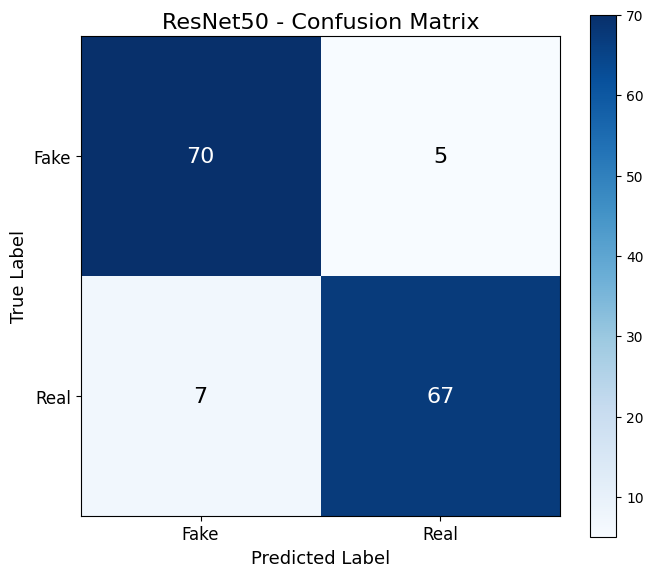

In [61]:
# ============================================================
# CELL 56 — CONFUSION MATRIX VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("ResNet50 - Confusion Matrix", fontsize=16)
plt.colorbar()

class_names = ["Fake", "Real"]

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontsize=12)
plt.yticks(tick_marks, class_names, fontsize=12)

# Add values inside cells
threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=16,
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)
plt.tight_layout()
plt.show()

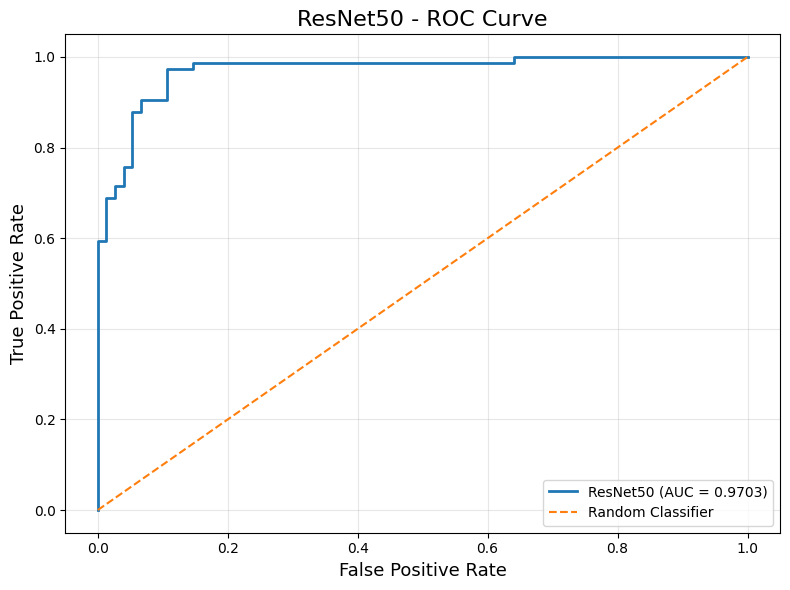

ROC-AUC = 0.9703 (97.03%)


In [62]:
# ============================================================
# CELL 57 — ROC CURVE WITH AUC
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ResNet50 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title("ResNet50 - ROC Curve", fontsize=16)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print(f"ROC-AUC = {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("=" * 60)

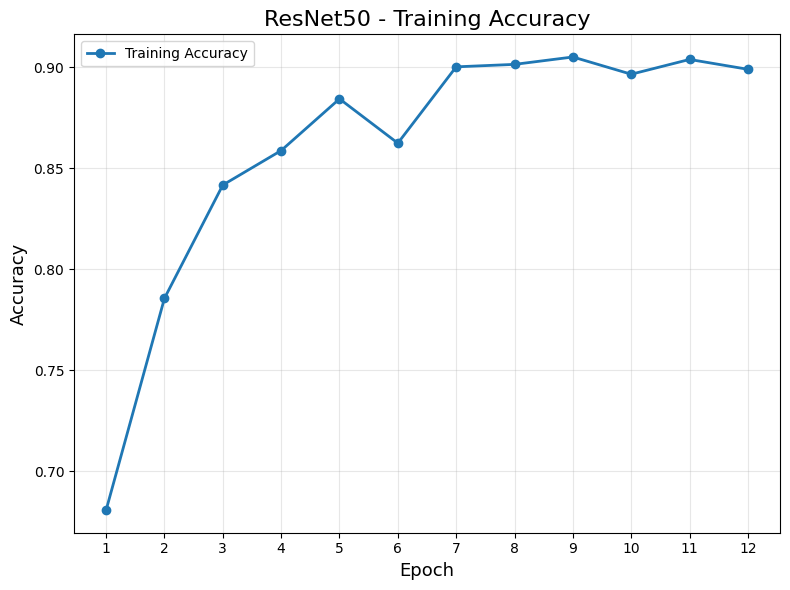

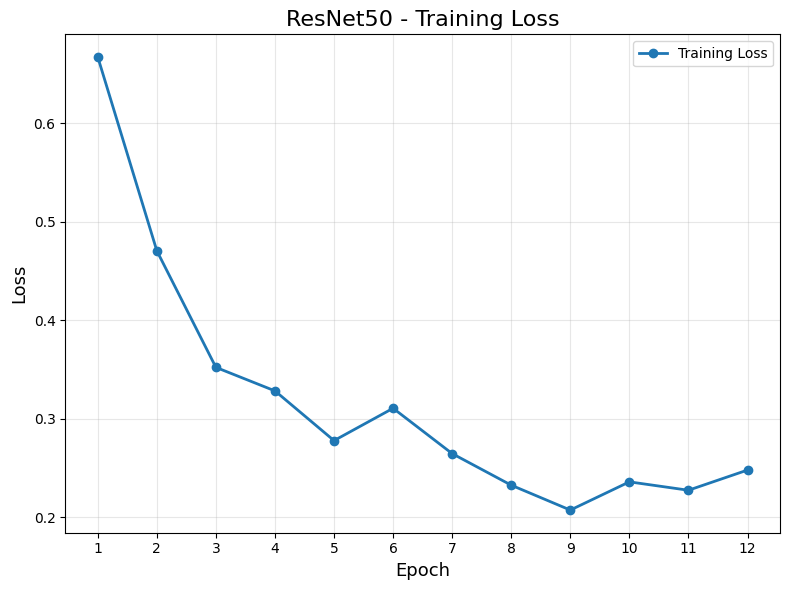

TRAINING CURVES GENERATED
Best training-loss epoch : 9
Best training loss       : 0.2072


In [63]:
# ============================================================
# CELL 58 — FINAL TRAINING CURVES
# ============================================================

history = final_history.history

epochs = range(1, len(history["accuracy"]) + 1)

# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.title("ResNet50 - Training Accuracy", fontsize=16)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.title("ResNet50 - Training Loss", fontsize=16)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TRAINING CURVES GENERATED")
print("=" * 60)

best_epoch = np.argmin(history["loss"]) + 1
best_loss = min(history["loss"])

print(f"Best training-loss epoch : {best_epoch}")
print(f"Best training loss       : {best_loss:.4f}")

In [64]:
# ============================================================
# CELL 59 — SAVE FINAL RESNET50 MODEL
# ============================================================

model_path = "/content/ResNet50_FakeNews_Final.keras"

final_model.save(model_path)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)

print("Model path:")
print(model_path)

print("\nModel size:")
print(f"{os.path.getsize(model_path) / (1024 * 1024):.2f} MB")

print("\n✅ ResNet50 model saved successfully!")

FINAL MODEL SAVED
Model path:
/content/ResNet50_FakeNews_Final.keras

Model size:
93.69 MB

✅ ResNet50 model saved successfully!


In [65]:
# ============================================================
# CELL 60 — FINAL RESNET50 RESULTS SUMMARY
# ============================================================

# 5-Fold Cross-Validation results
cv_summary = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": [0.951515, 0.786585, 0.719512, 0.865854, 0.871951],
    "Precision": [0.918605, 0.711538, 0.636364, 0.787879, 0.939394],
    "Recall": [0.987500, 0.936709, 0.974684, 0.987342, 0.784810],
    "F1 Score": [0.951807, 0.808743, 0.770000, 0.876404, 0.855172]
})

# Independent test results
test_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Result": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("=" * 70)
print("RESNET50 — 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(cv_summary.to_string(index=False))

print("\n" + "=" * 70)
print("RESNET50 — INDEPENDENT TEST RESULTS")
print("=" * 70)

for metric, value in zip(
    test_summary["Metric"],
    test_summary["Result"]
):
    print(f"{metric:<12}: {value:.4f} ({value*100:.2f}%)")

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("CV images used       :", len(final_train_df))
print("Test images used     :", len(test_df))
print("CV Fake              :", (final_train_df["label"] == 0).sum())
print("CV Real              :", (final_train_df["label"] == 1).sum())
print("Test Fake            :", (test_df["label"] == 0).sum())
print("Test Real            :", (test_df["label"] == 1).sum())

print("\n✅ Results summary created successfully!")

RESNET50 — 5-FOLD CROSS-VALIDATION RESULTS
 Fold  Accuracy  Precision   Recall  F1 Score
    1  0.951515   0.918605 0.987500  0.951807
    2  0.786585   0.711538 0.936709  0.808743
    3  0.719512   0.636364 0.974684  0.770000
    4  0.865854   0.787879 0.987342  0.876404
    5  0.871951   0.939394 0.784810  0.855172

RESNET50 — INDEPENDENT TEST RESULTS
Accuracy    : 0.9195 (91.95%)
Precision   : 0.9306 (93.06%)
Recall      : 0.9054 (90.54%)
F1 Score    : 0.9178 (91.78%)
ROC-AUC     : 0.9703 (97.03%)

DATASET INFORMATION
CV images used       : 821
Test images used     : 149
CV Fake              : 425
CV Real              : 396
Test Fake            : 75
Test Real            : 74

✅ Results summary created successfully!


In [66]:
# ============================================================
# CELL 61 — EXPORT RESNET50 RESULTS TO EXCEL
# ============================================================

from openpyxl import Workbook

excel_path = "/content/ResNet50_Results.xlsx"

# Create workbook
wb = Workbook()

# ------------------------------------------------------------
# Sheet 1: Cross-Validation
# ------------------------------------------------------------

ws1 = wb.active
ws1.title = "5-Fold CV"

headers = ["Fold", "Accuracy", "Precision", "Recall", "F1 Score"]
ws1.append(headers)

for _, row in cv_summary.iterrows():
    ws1.append([
        int(row["Fold"]),
        row["Accuracy"],
        row["Precision"],
        row["Recall"],
        row["F1 Score"]
    ])

# Mean ± SD
ws1.append([])
ws1.append([
    "Mean ± SD",
    "83.91% ± 8.87%",
    "79.88% ± 13.06%",
    "93.42% ± 8.61%",
    "85.24% ± 6.92%"
])

# ------------------------------------------------------------
# Sheet 2: Independent Test
# ------------------------------------------------------------

ws2 = wb.create_sheet("Independent Test")

ws2.append(["Metric", "Value"])

for metric, value in zip(
    test_summary["Metric"],
    test_summary["Result"]
):
    ws2.append([metric, float(value)])

# ------------------------------------------------------------
# Sheet 3: Confusion Matrix
# ------------------------------------------------------------

ws3 = wb.create_sheet("Confusion Matrix")

ws3.append(["Actual / Predicted", "Fake", "Real"])
ws3.append(["Fake", int(cm[0, 0]), int(cm[0, 1])])
ws3.append(["Real", int(cm[1, 0]), int(cm[1, 1])])

# ------------------------------------------------------------
# Sheet 4: Dataset Information
# ------------------------------------------------------------

ws4 = wb.create_sheet("Dataset Information")

dataset_info = [
    ["Item", "Value"],
    ["CV Images", len(final_train_df)],
    ["CV Fake", (final_train_df["label"] == 0).sum()],
    ["CV Real", (final_train_df["label"] == 1).sum()],
    ["Test Images", len(test_df)],
    ["Test Fake", (test_df["label"] == 0).sum()],
    ["Test Real", (test_df["label"] == 1).sum()],
    ["Excluded Corrupted CV Images", 29],
]

for row in dataset_info:
    ws4.append(row)

# Save workbook
wb.save(excel_path)

print("=" * 60)
print("RESNET50 RESULTS EXPORTED")
print("=" * 60)

print("\nExcel file:")
print(excel_path)

print("\nSheets created:")
print("1. 5-Fold CV")
print("2. Independent Test")
print("3. Confusion Matrix")
print("4. Dataset Information")

print("\n✅ Excel export completed successfully!")

RESNET50 RESULTS EXPORTED

Excel file:
/content/ResNet50_Results.xlsx

Sheets created:
1. 5-Fold CV
2. Independent Test
3. Confusion Matrix
4. Dataset Information

✅ Excel export completed successfully!


In [67]:
# ============================================================
# CELL 62 — SAVE RESNET50 FIGURES
# ============================================================

# ------------------------------------------------------------
# 1. Save Confusion Matrix
# ------------------------------------------------------------

cm_path = "/content/ResNet50_Confusion_Matrix.png"

plt.figure(figsize=(7, 6))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("ResNet50 - Confusion Matrix", fontsize=16)

plt.colorbar()

class_names = ["Fake", "Real"]
tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    fontsize=12
)

plt.yticks(
    tick_marks,
    class_names,
    fontsize=12
)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16,
            color="white" if cm[i, j] > threshold else "black"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)

plt.tight_layout()
plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ------------------------------------------------------------
# 2. Save ROC Curve
# ------------------------------------------------------------

roc_path = "/content/ResNet50_ROC_Curve.png"

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ResNet50 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)

plt.title(
    "ResNet50 - ROC Curve",
    fontsize=16
)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ------------------------------------------------------------
# 3. Save Training Accuracy
# ------------------------------------------------------------

accuracy_path = "/content/ResNet50_Training_Accuracy.png"

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.title("ResNet50 - Training Accuracy", fontsize=16)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# ------------------------------------------------------------
# 4. Save Training Loss
# ------------------------------------------------------------

loss_path = "/content/ResNet50_Training_Loss.png"

plt.figure(figsize=(8, 6))

plt.plot(
    epochs,
    history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)
plt.title("ResNet50 - Training Loss", fontsize=16)

plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)
plt.close()


print("=" * 60)
print("RESNET50 FIGURES SAVED")
print("=" * 60)

print("\n1. Confusion Matrix:")
print(cm_path)

print("\n2. ROC Curve:")
print(roc_path)

print("\n3. Training Accuracy:")
print(accuracy_path)

print("\n4. Training Loss:")
print(loss_path)

print("\nAll figures saved at 300 DPI.")
print("✅ Figure export completed successfully!")

RESNET50 FIGURES SAVED

1. Confusion Matrix:
/content/ResNet50_Confusion_Matrix.png

2. ROC Curve:
/content/ResNet50_ROC_Curve.png

3. Training Accuracy:
/content/ResNet50_Training_Accuracy.png

4. Training Loss:
/content/ResNet50_Training_Loss.png

All figures saved at 300 DPI.
✅ Figure export completed successfully!


In [68]:
# ============================================================
# CELL 63 — DOWNLOAD RESNET50 FILES
# ============================================================

from google.colab import files

print("=" * 60)
print("RESNET50 FILES READY FOR DOWNLOAD")
print("=" * 60)

# Download trained model
files.download("/content/ResNet50_FakeNews_Final.keras")

# Download Excel results
files.download("/content/ResNet50_Results.xlsx")

# Download Confusion Matrix
files.download("/content/ResNet50_Confusion_Matrix.png")

# Download ROC Curve
files.download("/content/ResNet50_ROC_Curve.png")

# Download Training Accuracy
files.download("/content/ResNet50_Training_Accuracy.png")

# Download Training Loss
files.download("/content/ResNet50_Training_Loss.png")

print("\n✅ Download commands completed!")

RESNET50 FILES READY FOR DOWNLOAD


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download commands completed!


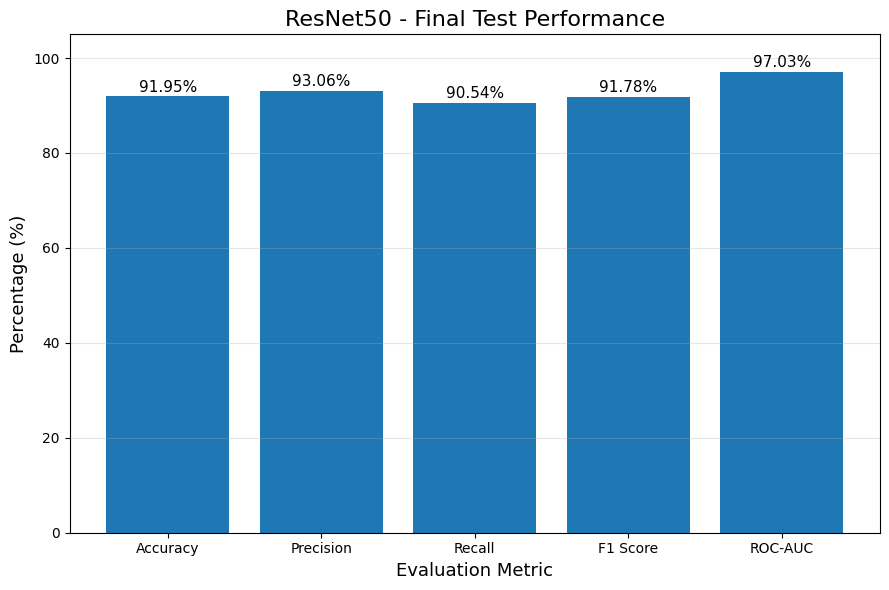

PERFORMANCE GRAPH SAVED
/content/ResNet50_Final_Performance.png


In [69]:
# ============================================================
# CELL 64 — RESNET50 PERFORMANCE METRICS GRAPH
# ============================================================

metrics_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

metrics_values = [
    accuracy * 100,
    precision * 100,
    recall * 100,
    f1 * 100,
    roc_auc * 100
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metrics_names,
    metrics_values
)

plt.ylabel("Percentage (%)", fontsize=13)
plt.xlabel("Evaluation Metric", fontsize=13)
plt.title(
    "ResNet50 - Final Test Performance",
    fontsize=16
)

plt.ylim(0, 105)

# Display values above bars
for bar, value in zip(bars, metrics_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

performance_graph_path = (
    "/content/ResNet50_Final_Performance.png"
)

plt.savefig(
    performance_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("PERFORMANCE GRAPH SAVED")
print("=" * 60)
print(performance_graph_path)

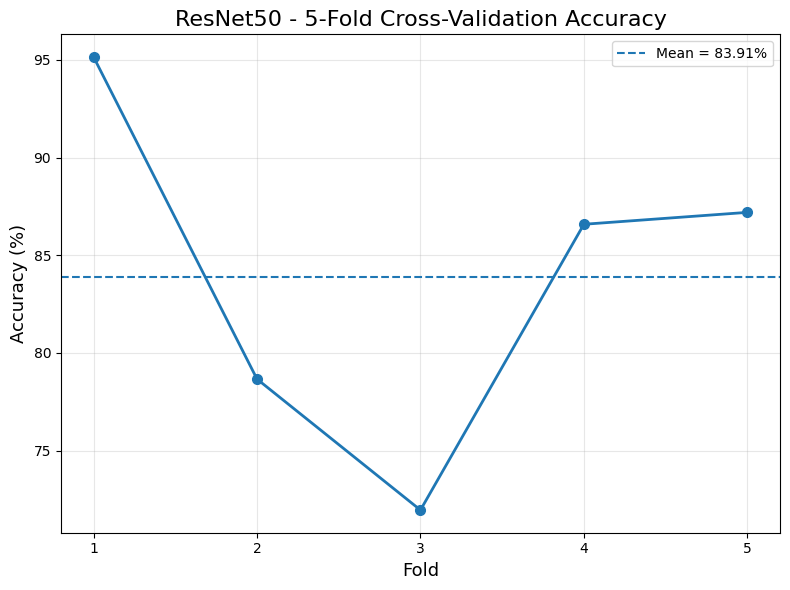

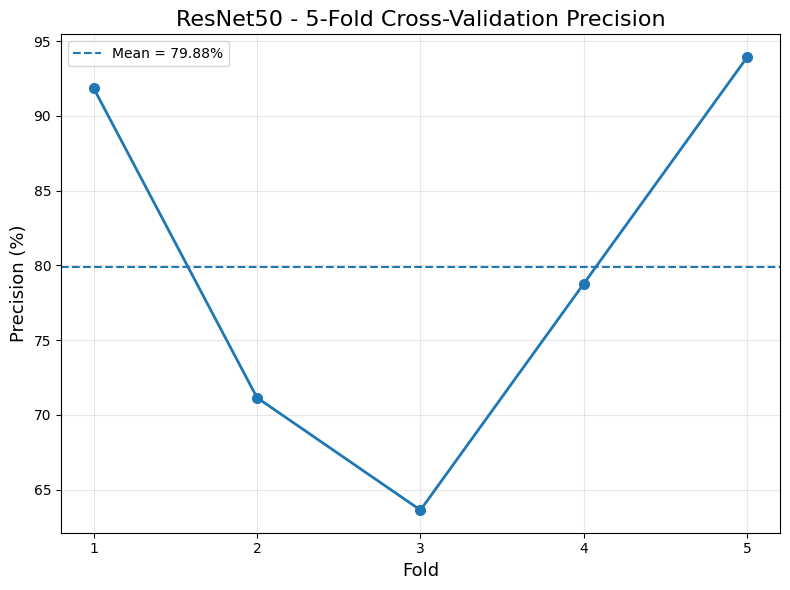

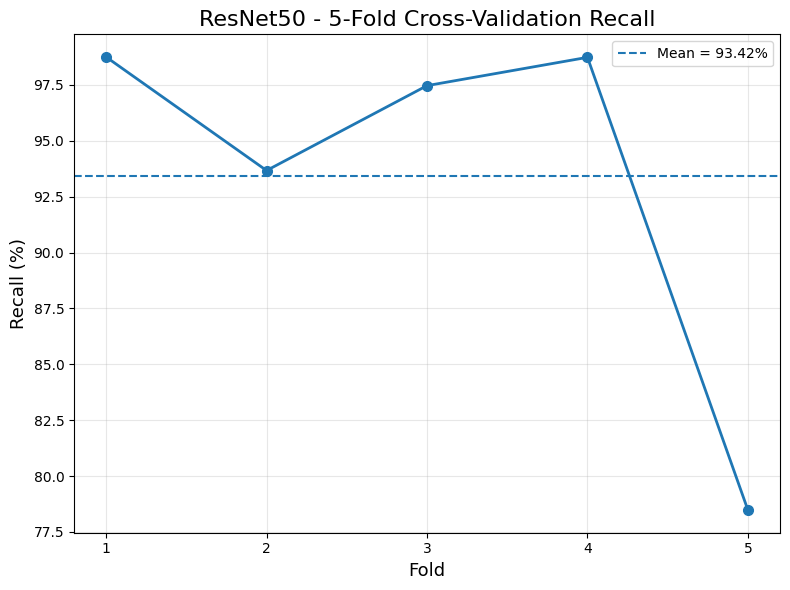

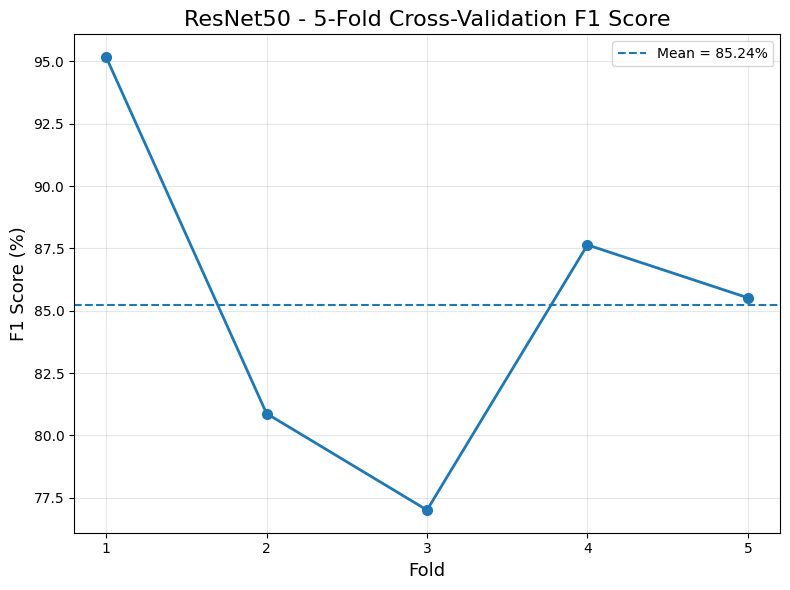

ALL 5-FOLD CV GRAPHS GENERATED


In [70]:
# ============================================================
# CELL 64 — 5-FOLD CROSS-VALIDATION GRAPHS
# ============================================================

fold_numbers = cv_summary["Fold"]

metrics_to_plot = [
    ("Accuracy", "5-Fold Cross-Validation Accuracy"),
    ("Precision", "5-Fold Cross-Validation Precision"),
    ("Recall", "5-Fold Cross-Validation Recall"),
    ("F1 Score", "5-Fold Cross-Validation F1 Score")
]

for metric, title in metrics_to_plot:

    plt.figure(figsize=(8, 6))

    values = cv_summary[metric] * 100

    plt.plot(
        fold_numbers,
        values,
        marker="o",
        linewidth=2,
        markersize=7
    )

    plt.axhline(
        values.mean(),
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {values.mean():.2f}%"
    )

    plt.xlabel("Fold", fontsize=13)
    plt.ylabel(metric + " (%)", fontsize=13)
    plt.title(
        f"ResNet50 - {title}",
        fontsize=16
    )

    plt.xticks([1, 2, 3, 4, 5])
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

print("=" * 60)
print("ALL 5-FOLD CV GRAPHS GENERATED")
print("=" * 60)

Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 409ms/step - accuracy: 0.6067 - loss: 0.8191 - precision: 0.5707 - recall: 0.7405 - val_accuracy: 0.7455 - val_loss: 0.5129 - val_precision: 0.6667 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 340ms/step - accuracy: 0.7576 - loss: 0.5653 - precision: 0.7249 - recall: 0.8006 - val_accuracy: 0.8727 - val_loss: 0.3789 - val_precision: 0.8242 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 309ms/step - accuracy: 0.8155 - loss: 0.4337 - precision: 0.7794 - recall: 0.8608 - val_accuracy: 0.8848 - val_loss: 0.3187 - val_precision: 0.8427 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 257ms/step - accuracy: 0.8445 - loss: 0.3903 - precision: 0.8262 - recall: 0.8576 - val_accuracy: 0.9091 - val_loss: 0.2696 - val_precision: 0.8824 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 5/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 23

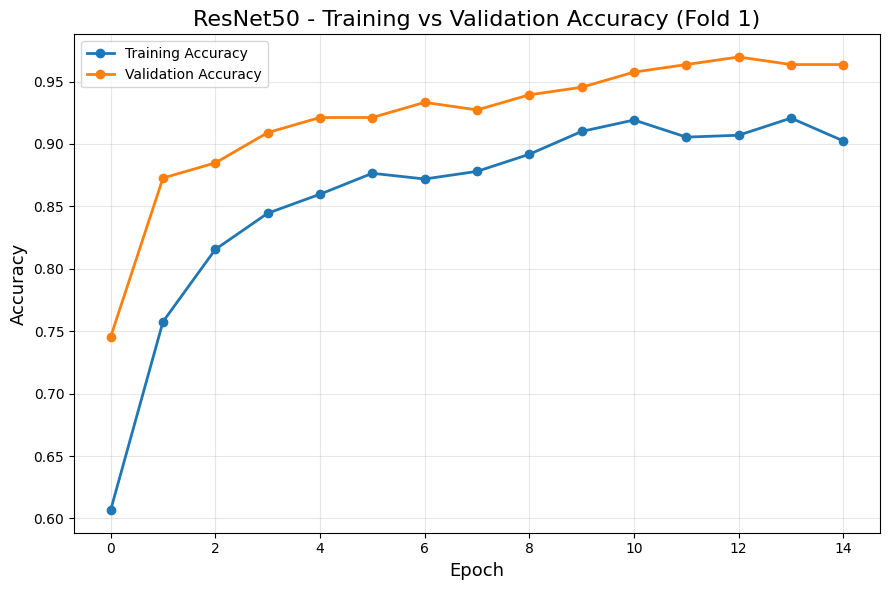

TRAINING vs VALIDATION ACCURACY GRAPH


In [72]:
# ============================================================
# CELL 65 — TRAINING VS VALIDATION ACCURACY
# ============================================================

# Select Fold 1
fold_number = 1

train_df_fold, val_df_fold = folds[fold_number - 1]

train_dataset_fold = create_dataset(
    train_df_fold,
    training=True
)

val_dataset_fold = create_dataset(
    val_df_fold,
    training=False
)

# Build a fresh ResNet50 model
comparison_model = build_resnet50()

# Fresh callbacks
comparison_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train
comparison_history = comparison_model.fit(
    train_dataset_fold,
    validation_data=val_dataset_fold,
    epochs=15,
    callbacks=comparison_callbacks,
    verbose=1
)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(
    comparison_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    comparison_history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.title(
    "ResNet50 - Training vs Validation Accuracy (Fold 1)",
    fontsize=16
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TRAINING vs VALIDATION ACCURACY GRAPH")
print("=" * 60)

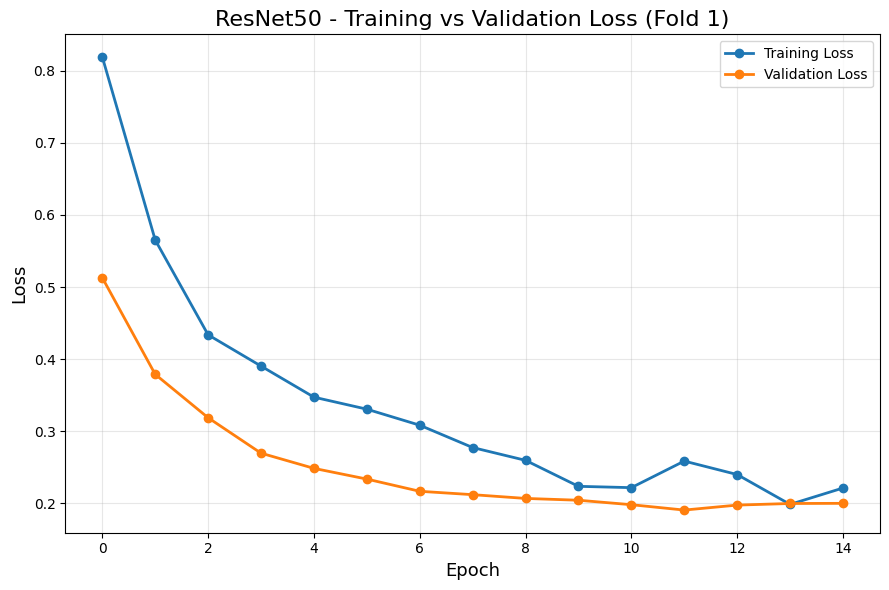

TRAINING vs VALIDATION LOSS GRAPH


In [73]:
# ============================================================
# CELL 66 — TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    comparison_history.history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    comparison_history.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.title(
    "ResNet50 - Training vs Validation Loss (Fold 1)",
    fontsize=16
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TRAINING vs VALIDATION LOSS GRAPH")
print("=" * 60)

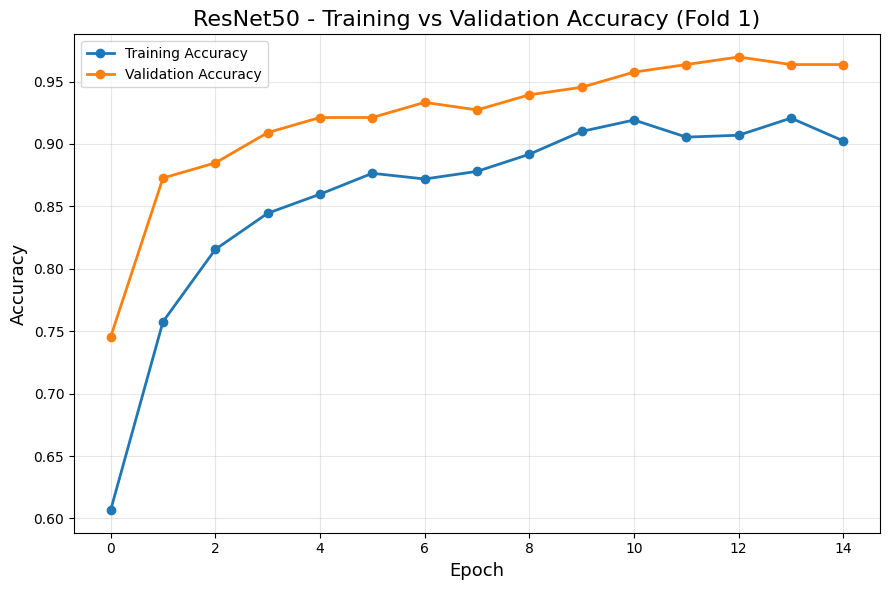

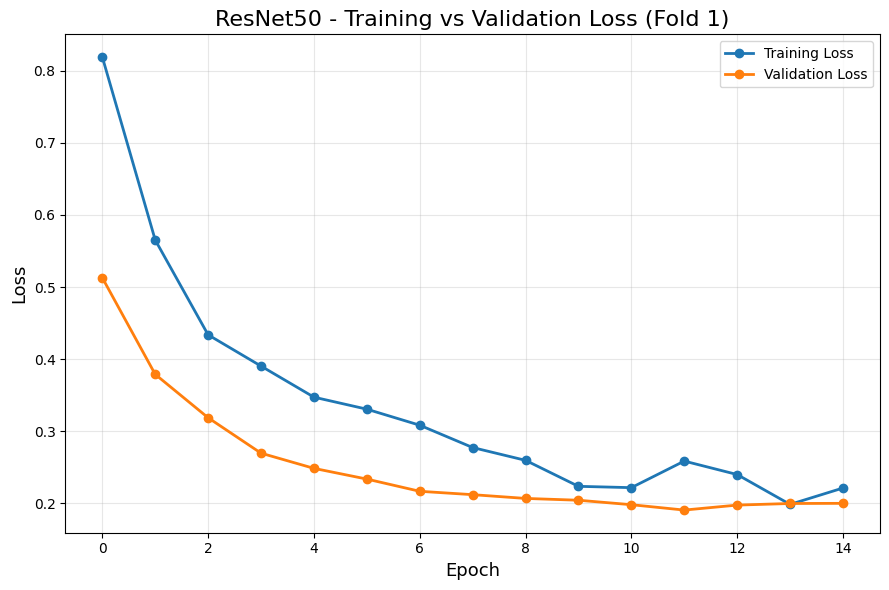

TRAINING/VALIDATION GRAPHS SAVED

Accuracy graph:
/content/ResNet50_Training_vs_Validation_Accuracy.png

Loss graph:
/content/ResNet50_Training_vs_Validation_Loss.png

✅ Both graphs saved at 300 DPI!


In [74]:
# ============================================================
# CELL 67 — SAVE TRAINING vs VALIDATION GRAPHS
# ============================================================

# ------------------------------------------------------------
# 1. Training vs Validation Accuracy
# ------------------------------------------------------------

accuracy_val_path = "/content/ResNet50_Training_vs_Validation_Accuracy.png"

plt.figure(figsize=(9, 6))

plt.plot(
    comparison_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    comparison_history.history["val_accuracy"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)

plt.title(
    "ResNet50 - Training vs Validation Accuracy (Fold 1)",
    fontsize=16
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    accuracy_val_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ------------------------------------------------------------
# 2. Training vs Validation Loss
# ------------------------------------------------------------

loss_val_path = "/content/ResNet50_Training_vs_Validation_Loss.png"

plt.figure(figsize=(9, 6))

plt.plot(
    comparison_history.history["loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    comparison_history.history["val_loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.title(
    "ResNet50 - Training vs Validation Loss (Fold 1)",
    fontsize=16
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    loss_val_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


print("=" * 60)
print("TRAINING/VALIDATION GRAPHS SAVED")
print("=" * 60)

print("\nAccuracy graph:")
print(accuracy_val_path)

print("\nLoss graph:")
print(loss_val_path)

print("\n✅ Both graphs saved at 300 DPI!")

RETRAINING ALL 5 FOLDS FOR TRAINING/VALIDATION CURVES

STARTING FOLD 1
Epoch 1/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 29s 419ms/step - accuracy: 0.6677 - loss: 0.7179 - precision: 0.6332 - recall: 0.7373 - val_accuracy: 0.7818 - val_loss: 0.4986 - val_precision: 0.7000 - val_recall: 0.9625 - learning_rate: 1.0000e-04
Epoch 2/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 259ms/step - accuracy: 0.7698 - loss: 0.4995 - precision: 0.7636 - recall: 0.7563 - val_accuracy: 0.8970 - val_loss: 0.3182 - val_precision: 0.8539 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 3/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.8262 - loss: 0.3974 - precision: 0.8176 - recall: 0.8228 - val_accuracy: 0.9212 - val_loss: 0.2631 - val_precision: 0.8941 - val_recall: 0.9500 - learning_rate: 1.0000e-04
Epoch 4/15
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 264ms/step - accuracy: 0.8338 - loss: 0.3716 - precision: 0.8328 - recall: 0.8196 - val_accuracy: 0.9333 - val_loss: 0.2321 - val_precision: 0.9157 - val_recall: 0.9500 -

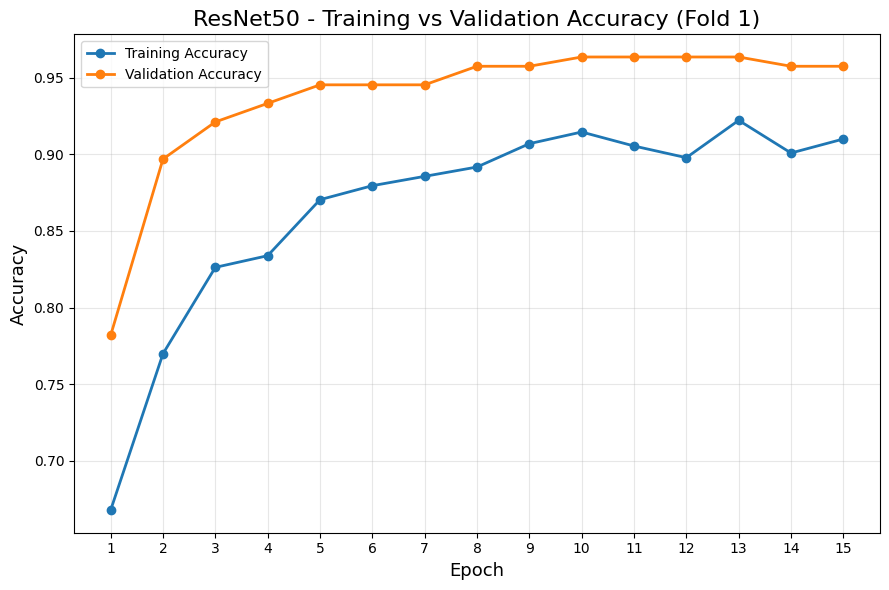

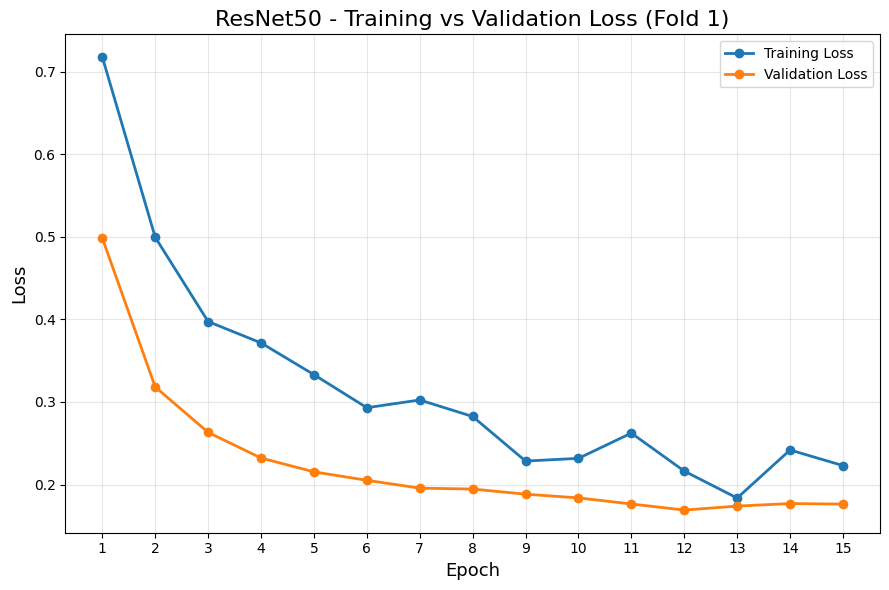

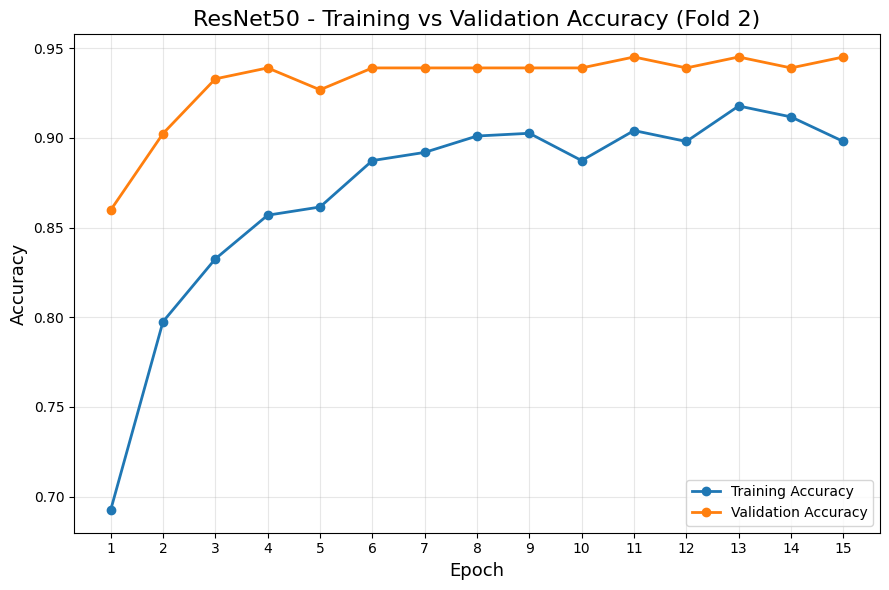

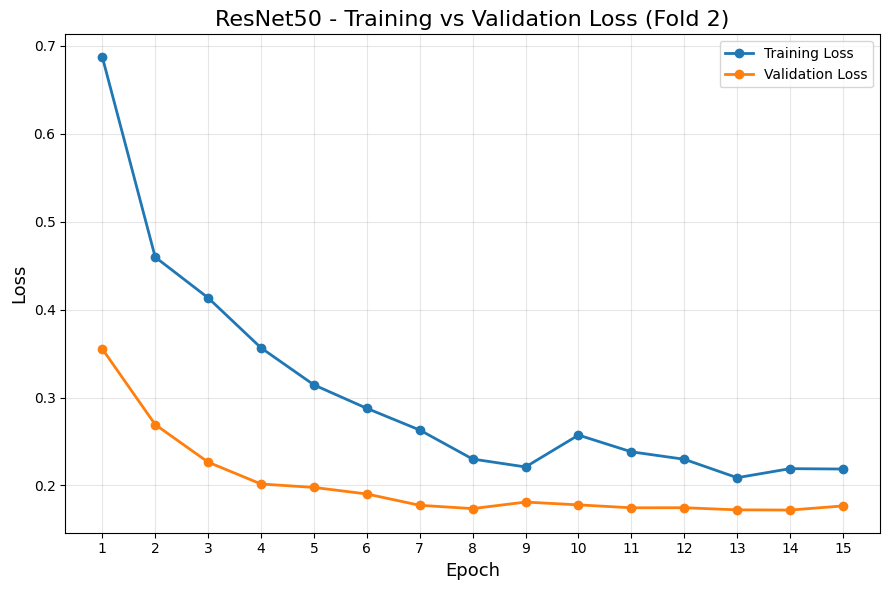

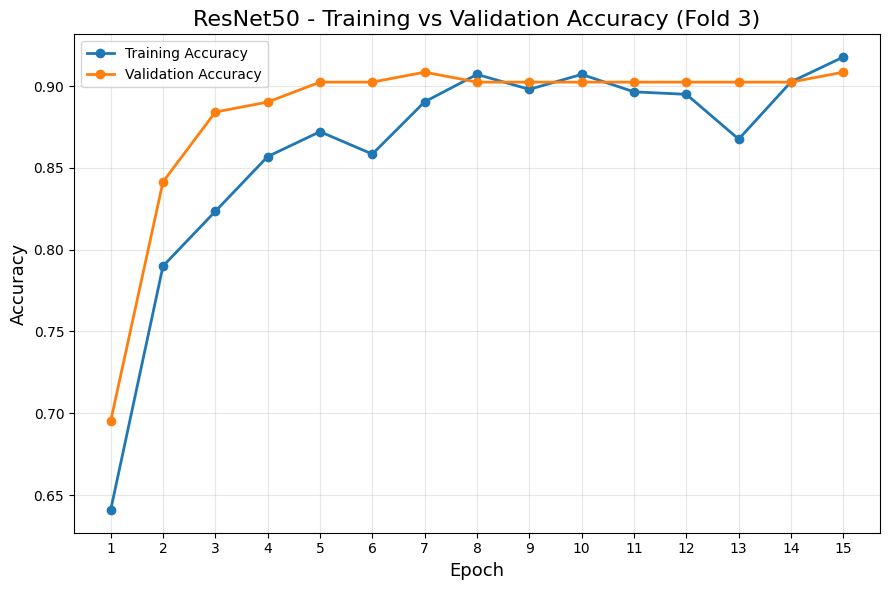

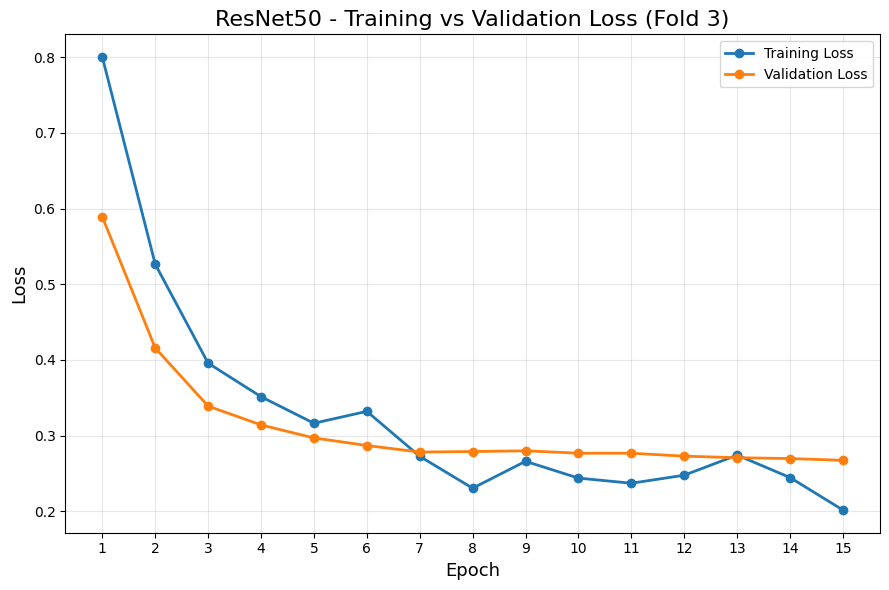

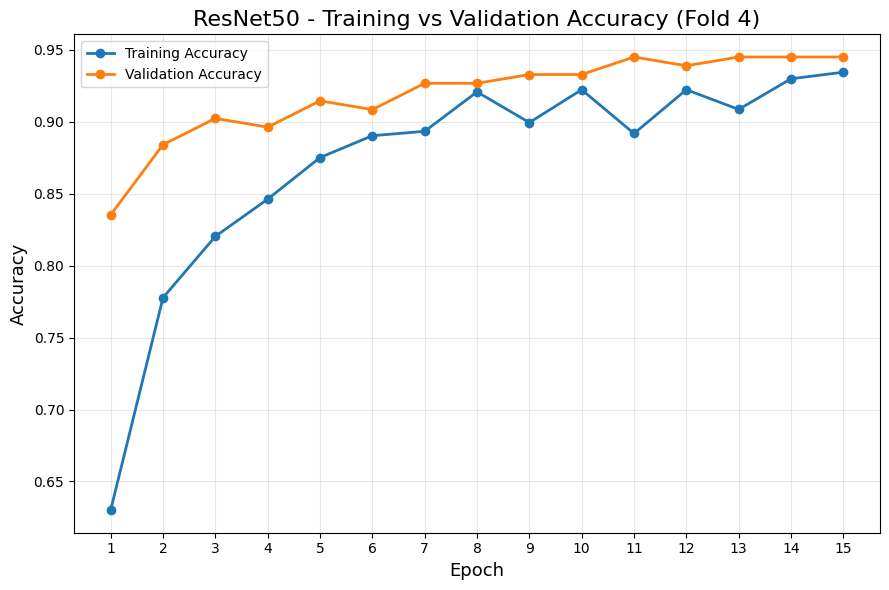

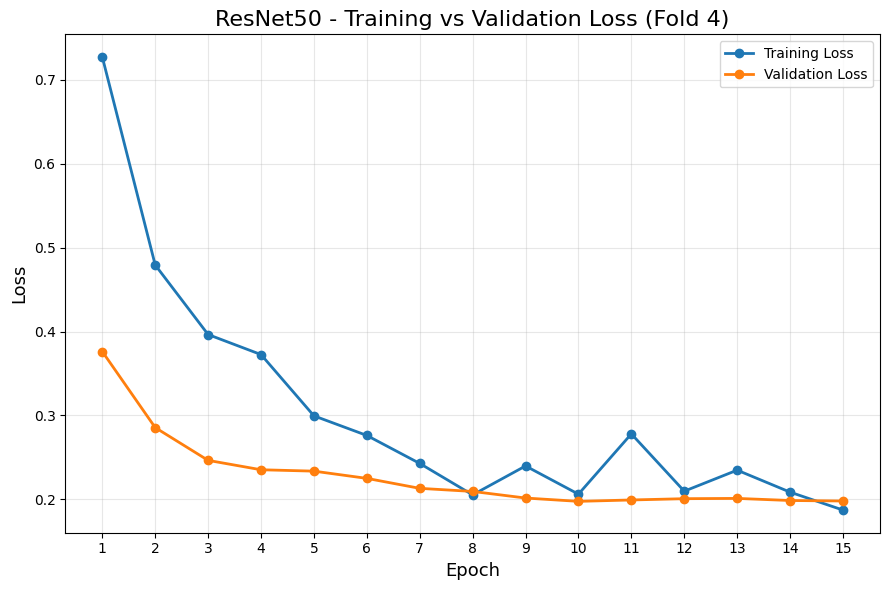

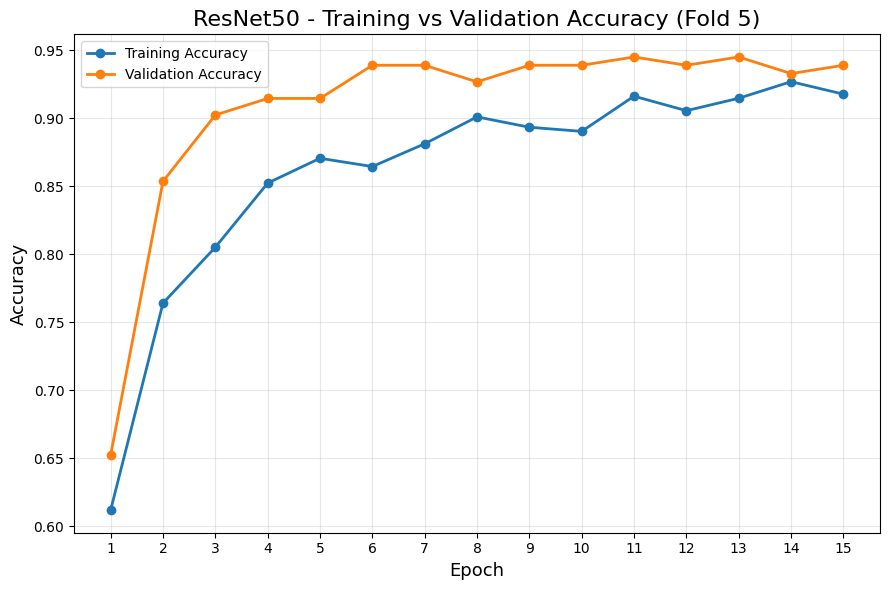

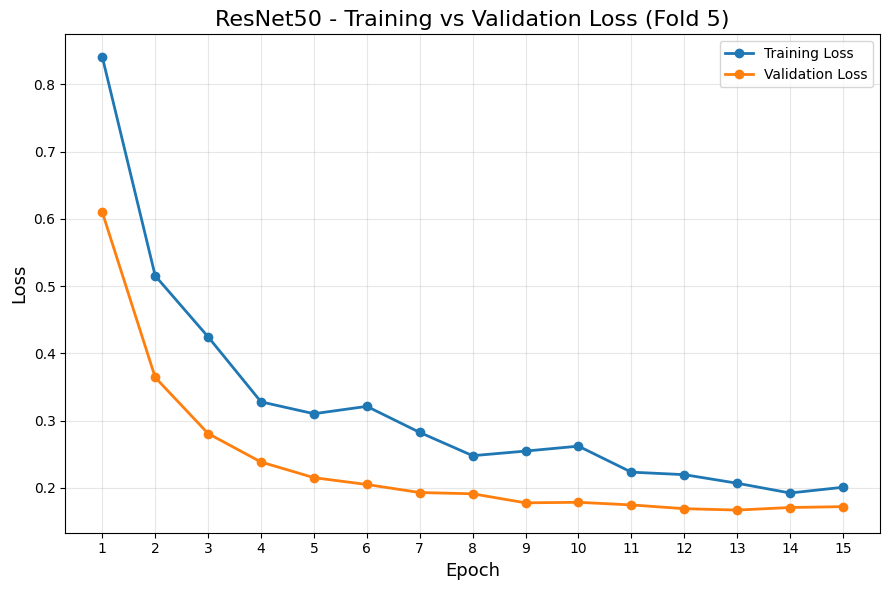


10 GRAPHS GENERATED SUCCESSFULLY

Fold 1:
  Accuracy → /content/ResNet50_Fold_1_Training_vs_Validation_Accuracy.png
  Loss     → /content/ResNet50_Fold_1_Training_vs_Validation_Loss.png

Fold 2:
  Accuracy → /content/ResNet50_Fold_2_Training_vs_Validation_Accuracy.png
  Loss     → /content/ResNet50_Fold_2_Training_vs_Validation_Loss.png

Fold 3:
  Accuracy → /content/ResNet50_Fold_3_Training_vs_Validation_Accuracy.png
  Loss     → /content/ResNet50_Fold_3_Training_vs_Validation_Loss.png

Fold 4:
  Accuracy → /content/ResNet50_Fold_4_Training_vs_Validation_Accuracy.png
  Loss     → /content/ResNet50_Fold_4_Training_vs_Validation_Loss.png

Fold 5:
  Accuracy → /content/ResNet50_Fold_5_Training_vs_Validation_Accuracy.png
  Loss     → /content/ResNet50_Fold_5_Training_vs_Validation_Loss.png


In [76]:
# ============================================================
# CELL 68 — TRAINING vs VALIDATION GRAPHS FOR ALL 5 FOLDS
# ============================================================

all_fold_histories = {}

print("=" * 70)
print("RETRAINING ALL 5 FOLDS FOR TRAINING/VALIDATION CURVES")
print("=" * 70)

for fold_number in range(1, 6):

    print("\n" + "=" * 70)
    print(f"STARTING FOLD {fold_number}")
    print("=" * 70)

    # Get fold data
    train_df_fold, val_df_fold = folds[fold_number - 1]

    # Create datasets
    train_dataset_fold = create_dataset(
        train_df_fold,
        training=True
    )

    val_dataset_fold = create_dataset(
        val_df_fold,
        training=False
    )

    # Build a completely fresh ResNet50
    fold_model = build_resnet50()

    # Fresh callbacks for THIS fold
    fold_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # Train
    fold_history = fold_model.fit(
        train_dataset_fold,
        validation_data=val_dataset_fold,
        epochs=15,
        callbacks=fold_callbacks,
        verbose=1
    )

    # Store history
    all_fold_histories[fold_number] = fold_history.history

    print(f"\nFold {fold_number} completed!")

print("\n" + "=" * 70)
print("ALL 5 FOLDS COMPLETED")
print("=" * 70)


# ============================================================
# GENERATE GRAPHS
# ============================================================

for fold_number in range(1, 6):

    history = all_fold_histories[fold_number]

    epochs_fold = range(
        1,
        len(history["accuracy"]) + 1
    )

    # --------------------------------------------------------
    # TRAINING vs VALIDATION ACCURACY
    # --------------------------------------------------------

    plt.figure(figsize=(9, 6))

    plt.plot(
        epochs_fold,
        history["accuracy"],
        marker="o",
        linewidth=2,
        label="Training Accuracy"
    )

    plt.plot(
        epochs_fold,
        history["val_accuracy"],
        marker="o",
        linewidth=2,
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch", fontsize=13)
    plt.ylabel("Accuracy", fontsize=13)

    plt.title(
        f"ResNet50 - Training vs Validation Accuracy (Fold {fold_number})",
        fontsize=16
    )

    plt.xticks(list(epochs_fold))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    accuracy_path = (
        f"/content/ResNet50_Fold_{fold_number}_"
        f"Training_vs_Validation_Accuracy.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


    # --------------------------------------------------------
    # TRAINING vs VALIDATION LOSS
    # --------------------------------------------------------

    plt.figure(figsize=(9, 6))

    plt.plot(
        epochs_fold,
        history["loss"],
        marker="o",
        linewidth=2,
        label="Training Loss"
    )

    plt.plot(
        epochs_fold,
        history["val_loss"],
        marker="o",
        linewidth=2,
        label="Validation Loss"
    )

    plt.xlabel("Epoch", fontsize=13)
    plt.ylabel("Loss", fontsize=13)

    plt.title(
        f"ResNet50 - Training vs Validation Loss (Fold {fold_number})",
        fontsize=16
    )

    plt.xticks(list(epochs_fold))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    loss_path = (
        f"/content/ResNet50_Fold_{fold_number}_"
        f"Training_vs_Validation_Loss.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


print("\n" + "=" * 70)
print("10 GRAPHS GENERATED SUCCESSFULLY")
print("=" * 70)

for fold_number in range(1, 6):
    print(f"\nFold {fold_number}:")
    print(
        f"  Accuracy → "
        f"/content/ResNet50_Fold_{fold_number}_"
        f"Training_vs_Validation_Accuracy.png"
    )
    print(
        f"  Loss     → "
        f"/content/ResNet50_Fold_{fold_number}_"
        f"Training_vs_Validation_Loss.png"
    )

In [78]:
# ============================================================
# CELL 69 — PRINT FINAL RESNET50 EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("                 RESNET50 FINAL EVALUATION SUMMARY")
print("=" * 75)

print("\nDATASET INFORMATION")
print("-" * 75)
print(f"5-Fold CV images       : {len(final_train_df)}")
print(f"CV Fake images         : {(final_train_df['label'] == 0).sum()}")
print(f"CV Real images         : {(final_train_df['label'] == 1).sum()}")
print(f"Independent test       : {len(test_df)}")
print(f"Test Fake images       : {(test_df['label'] == 0).sum()}")
print(f"Test Real images       : {(test_df['label'] == 1).sum()}")

print("\n5-FOLD CROSS-VALIDATION RESULTS")
print("-" * 75)
print(f"Accuracy   : 83.91% ± 8.87%")
print(f"Precision  : 79.88% ± 13.06%")
print(f"Recall     : 93.42% ± 8.61%")
print(f"F1 Score   : 85.24% ± 6.92%")

print("\nINDEPENDENT TEST RESULTS")
print("-" * 75)
print(f"Accuracy   : {accuracy * 100:.2f}%")
print(f"Precision  : {precision * 100:.2f}%")
print(f"Recall     : {recall * 100:.2f}%")
print(f"F1 Score   : {f1 * 100:.2f}%")
print(f"ROC-AUC    : {roc_auc * 100:.2f}%")
print(f"Test Loss  : 0.2207")

print("\nCONFUSION MATRIX")
print("-" * 75)
print("                 Predicted")
print("                 Fake    Real")
print(f"Actual Fake      {cm[0,0]:4d}    {cm[0,1]:4d}")
print(f"Actual Real      {cm[1,0]:4d}    {cm[1,1]:4d}")

print("\nPREDICTION SUMMARY")
print("-" * 75)
print(f"Correct predictions   : {cm[0,0] + cm[1,1]} / {len(test_df)}")
print(f"Incorrect predictions : {cm[0,1] + cm[1,0]} / {len(test_df)}")

print("\n" + "=" * 75)
print("                 RESNET50 EVALUATION COMPLETE")
print("=" * 75)


                 RESNET50 FINAL EVALUATION SUMMARY

DATASET INFORMATION
---------------------------------------------------------------------------
5-Fold CV images       : 821
CV Fake images         : 425
CV Real images         : 396
Independent test       : 149
Test Fake images       : 75
Test Real images       : 74

5-FOLD CROSS-VALIDATION RESULTS
---------------------------------------------------------------------------
Accuracy   : 83.91% ± 8.87%
Precision  : 79.88% ± 13.06%
Recall     : 93.42% ± 8.61%
F1 Score   : 85.24% ± 6.92%

INDEPENDENT TEST RESULTS
---------------------------------------------------------------------------
Accuracy   : 91.95%
Precision  : 93.06%
Recall     : 90.54%
F1 Score   : 91.78%
ROC-AUC    : 97.03%
Test Loss  : 0.2207

CONFUSION MATRIX
---------------------------------------------------------------------------
                 Predicted
                 Fake    Real
Actual Fake        70       5
Actual Real         7      67

PREDICTION SUMMARY
----

In [80]:
# ============================================================
# CELL 70 — INSTALL SHAP AND LIME
# ============================================================

!pip install -q shap lime

print("=" * 60)
print("SHAP AND LIME INSTALLED")
print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
SHAP AND LIME INSTALLED


EXPLAINABILITY TEST IMAGE

Image: test_Fake_0000.jpg
True label     : Fake
Predicted label: Fake
Probability    : 0.0018
Confidence     : 99.82%

Image:


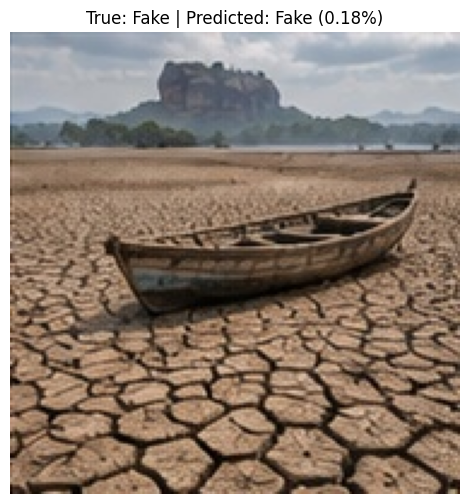

In [81]:
# ============================================================
# CELL 71 — SELECT TEST IMAGE
# ============================================================

# Select the first test image
image_index = 0

image_path = test_df.iloc[image_index]["filepath"]
true_label = test_df.iloc[image_index]["label"]

# Load image
from PIL import Image

explain_image = Image.open(image_path).convert("RGB")

# Resize for display
display_image = explain_image.resize((224, 224))

# Model prediction
image_array = np.array(display_image).astype(np.float32)

# Apply ResNet50 preprocessing
model_input = preprocess_input(
    np.expand_dims(image_array, axis=0)
)

prediction_probability = final_model.predict(
    model_input,
    verbose=0
)[0][0]

predicted_label = 1 if prediction_probability >= 0.5 else 0

label_names = {
    0: "Fake",
    1: "Real"
}

print("=" * 60)
print("EXPLAINABILITY TEST IMAGE")
print("=" * 60)

print("\nImage:", os.path.basename(image_path))

print(
    "True label     :",
    label_names[true_label]
)

print(
    "Predicted label:",
    label_names[predicted_label]
)

print(
    "Probability    :",
    f"{prediction_probability:.4f}"
)

print(
    "Confidence     :",
    f"{max(prediction_probability, 1-prediction_probability)*100:.2f}%"
)

print("\nImage:")

plt.figure(figsize=(6, 6))
plt.imshow(explain_image)
plt.axis("off")
plt.title(
    f"True: {label_names[true_label]} | "
    f"Predicted: {label_names[predicted_label]} "
    f"({prediction_probability:.2%})"
)
plt.show()

GENERATING SHAP EXPLANATION

Calculating SHAP values...
This may take some time on Colab.


  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:29, 29.24s/it]               



SHAP calculation completed!


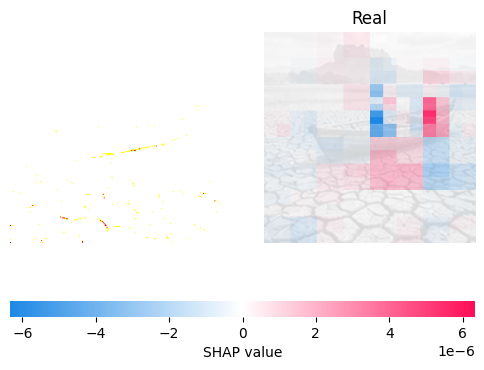


SHAP EXPLANATION GENERATED


In [82]:
# ============================================================
# CELL 72 — SHAP IMAGE EXPLANATION
# ============================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("GENERATING SHAP EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# Prepare image
# ------------------------------------------------------------

shap_image = np.array(
    explain_image.resize((224, 224))
).astype(np.float32)

shap_input = np.expand_dims(shap_image, axis=0)


# ------------------------------------------------------------
# Prediction function for SHAP
# ------------------------------------------------------------

def predict_for_shap(images):
    """
    SHAP prediction function.
    Input: RGB images
    Output: probability of Real class
    """

    images = np.array(images).astype(np.float32)

    processed_images = preprocess_input(images)

    return final_model.predict(
        processed_images,
        verbose=0
    ).reshape(-1, 1)


# ------------------------------------------------------------
# Create SHAP masker
# ------------------------------------------------------------

masker = shap.maskers.Image(
    "blur(32,32)",
    (224, 224, 3)
)


# ------------------------------------------------------------
# Create SHAP explainer
# ------------------------------------------------------------

explainer = shap.Explainer(
    predict_for_shap,
    masker,
    output_names=["Real"]
)


# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")
print("This may take some time on Colab.")

shap_values = explainer(
    shap_input,
    max_evals=1000,
    batch_size=16
)

print("\nSHAP calculation completed!")


# ------------------------------------------------------------
# Display SHAP explanation
# ------------------------------------------------------------

shap.image_plot(
    shap_values,
    show=True
)

print("\n" + "=" * 60)
print("SHAP EXPLANATION GENERATED")
print("=" * 60)

In [83]:
# ============================================================
# CELL 73 — SAVE SHAP EXPLANATION
# ============================================================

shap_path = "/content/ResNet50_SHAP_Explanation.png"

# Generate SHAP plot without displaying it
shap.image_plot(
    shap_values,
    show=False
)

plt.savefig(
    shap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close("all")

print("=" * 60)
print("SHAP EXPLANATION SAVED")
print("=" * 60)

print("\nFile:")
print(shap_path)

print("\nResolution: 300 DPI")
print("✅ SHAP figure saved successfully!")

SHAP EXPLANATION SAVED

File:
/content/ResNet50_SHAP_Explanation.png

Resolution: 300 DPI
✅ SHAP figure saved successfully!


GENERATING LIME EXPLANATION

Calculating LIME explanation...
This may take some time.


  0%|          | 0/1000 [00:00<?, ?it/s]


LIME calculation completed!


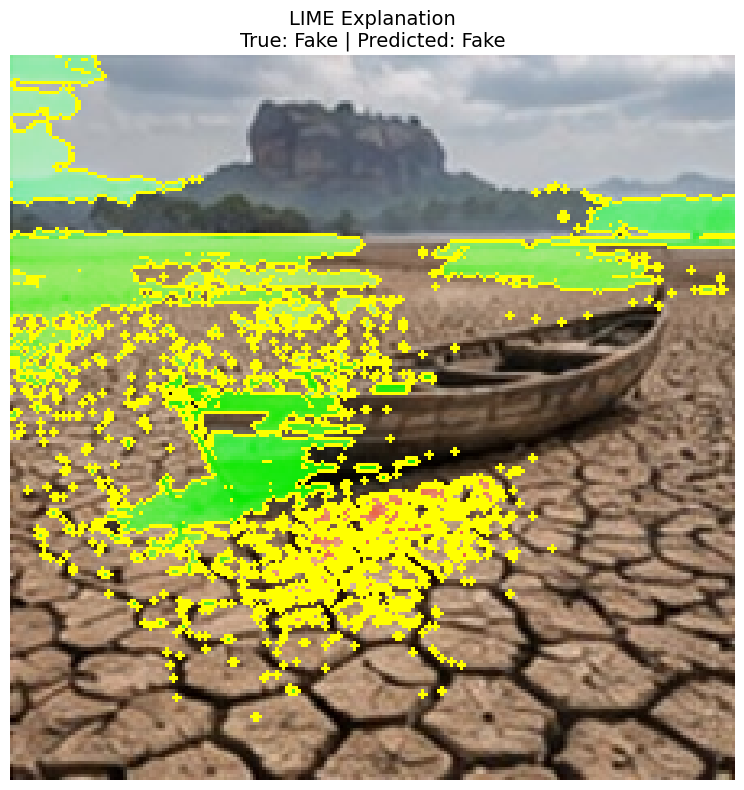


LIME EXPLANATION GENERATED


In [84]:
# ============================================================
# CELL 74 — LIME IMAGE EXPLANATION
# ============================================================

from lime import lime_image
from skimage.segmentation import mark_boundaries

print("=" * 60)
print("GENERATING LIME EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# Prepare image
# ------------------------------------------------------------

lime_image_array = np.array(
    explain_image.resize((224, 224))
).astype(np.float32)


# ------------------------------------------------------------
# LIME prediction function
# ------------------------------------------------------------

def predict_for_lime(images):

    images = np.array(images).astype(np.float32)

    processed_images = preprocess_input(images)

    real_probability = final_model.predict(
        processed_images,
        verbose=0
    ).reshape(-1)

    # Return probabilities for:
    # Class 0 = Fake
    # Class 1 = Real

    fake_probability = 1 - real_probability

    return np.column_stack([
        fake_probability,
        real_probability
    ])


# ------------------------------------------------------------
# Create LIME explainer
# ------------------------------------------------------------

lime_explainer = lime_image.LimeImageExplainer(
    random_state=SEED
)


# ------------------------------------------------------------
# Generate explanation
# ------------------------------------------------------------

print("\nCalculating LIME explanation...")
print("This may take some time.")

lime_explanation = lime_explainer.explain_instance(
    lime_image_array.astype(np.double),
    predict_for_lime,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

print("\nLIME calculation completed!")


# ------------------------------------------------------------
# Get explanation for predicted class
# ------------------------------------------------------------

predicted_class = predicted_label

lime_temp, lime_mask = lime_explanation.get_image_and_mask(
    predicted_class,
    positive_only=False,
    num_features=10,
    hide_rest=False
)


# ------------------------------------------------------------
# Display LIME explanation
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(
    mark_boundaries(
        lime_temp / 255.0,
        lime_mask
    )
)

plt.axis("off")

plt.title(
    f"LIME Explanation\n"
    f"True: {label_names[true_label]} | "
    f"Predicted: {label_names[predicted_class]}",
    fontsize=14
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("LIME EXPLANATION GENERATED")
print("=" * 60)

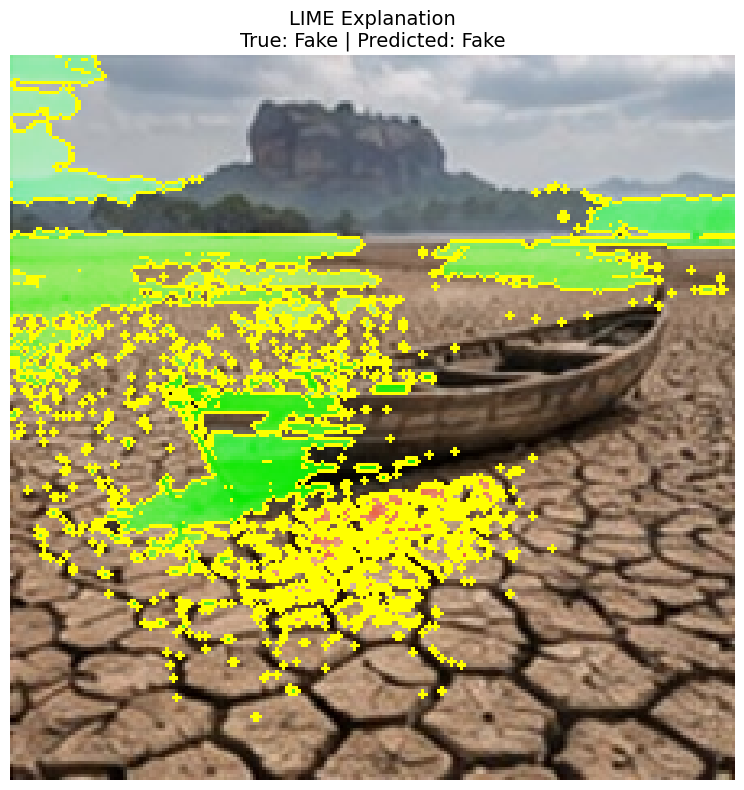

LIME EXPLANATION SAVED

File:
/content/ResNet50_LIME_Explanation.png

Resolution: 300 DPI
✅ LIME figure saved successfully!


In [85]:
# ============================================================
# CELL 75 — SAVE LIME EXPLANATION
# ============================================================

lime_path = "/content/ResNet50_LIME_Explanation.png"

plt.figure(figsize=(8, 8))

plt.imshow(
    mark_boundaries(
        lime_temp / 255.0,
        lime_mask
    )
)

plt.axis("off")

plt.title(
    f"LIME Explanation\n"
    f"True: {label_names[true_label]} | "
    f"Predicted: {label_names[predicted_class]}",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    lime_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("=" * 60)
print("LIME EXPLANATION SAVED")
print("=" * 60)

print("\nFile:")
print(lime_path)

print("\nResolution: 300 DPI")
print("✅ LIME figure saved successfully!")

GENERATING GRAD-CAM EXPLANATION
Backbone found: resnet50
Last convolutional layer: conv5_block3_out
Gradient calculation successful!


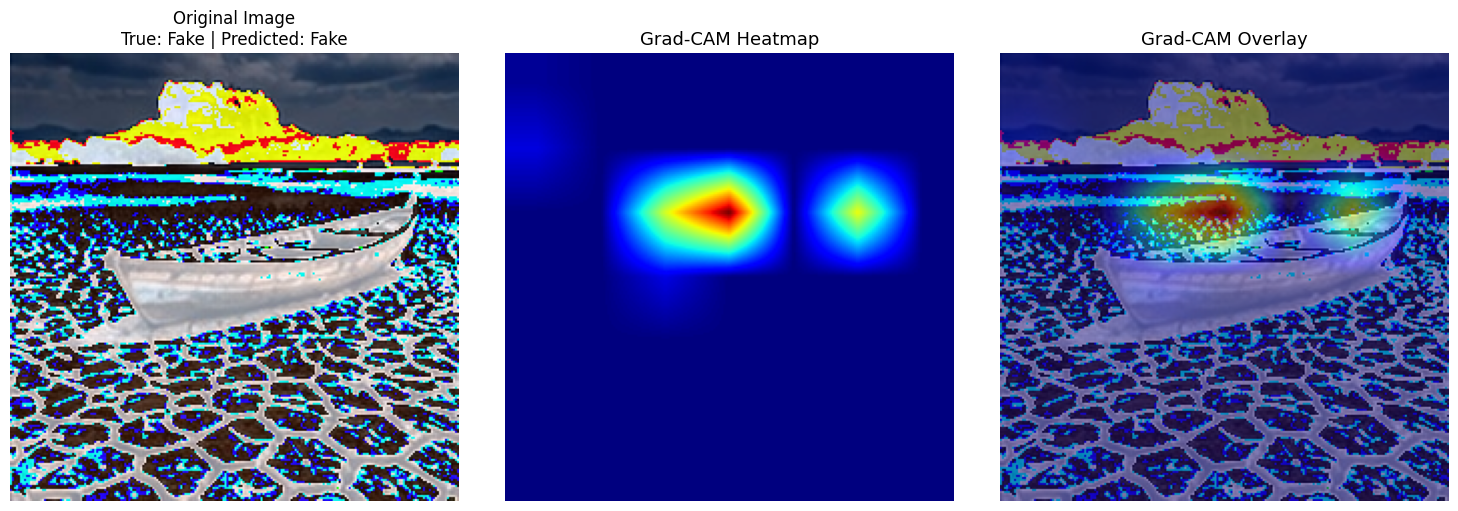


GRAD-CAM COMPLETED SUCCESSFULLY

Real probability : 0.0018
Fake probability : 0.9982
Predicted class  : Fake


In [87]:
# ============================================================
# CELL 76 — CORRECTED GRAD-CAM FOR RESNET50
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("GENERATING GRAD-CAM EXPLANATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Prepare image
# ------------------------------------------------------------

gradcam_image = np.array(
    explain_image.resize((224, 224))
).astype(np.float32)

gradcam_input = preprocess_input(
    np.expand_dims(gradcam_image, axis=0)
)

# ------------------------------------------------------------
# 2. Get ResNet50 backbone
# ------------------------------------------------------------

base_model = None

for layer in final_model.layers:
    if isinstance(layer, keras.Model):
        base_model = layer
        break

if base_model is None:
    raise ValueError("ResNet50 backbone not found.")

print("Backbone found:", base_model.name)


# ------------------------------------------------------------
# 3. Get last convolutional layer
# ------------------------------------------------------------

last_conv_layer = base_model.get_layer(
    "conv5_block3_out"
)

print(
    "Last convolutional layer:",
    last_conv_layer.name
)


# ------------------------------------------------------------
# 4. Create intermediate model
# ------------------------------------------------------------

conv_model = keras.Model(
    inputs=base_model.input,
    outputs=last_conv_layer.output
)


# ------------------------------------------------------------
# 5. Calculate gradients
# ------------------------------------------------------------

with tf.GradientTape() as tape:

    # Get convolutional feature maps
    conv_outputs = conv_model(
        gradcam_input,
        training=False
    )

    # Explicitly watch convolutional outputs
    tape.watch(conv_outputs)

    # Pass through the remaining classifier layers
    x = conv_outputs

    # GAP
    x = final_model.layers[2](x)

    # Batch Normalization
    x = final_model.layers[3](
        x,
        training=False
    )

    # Dropout
    x = final_model.layers[4](
        x,
        training=False
    )

    # Dense 128
    x = final_model.layers[5](x)

    # Dropout
    x = final_model.layers[6](
        x,
        training=False
    )

    # Final sigmoid output
    predictions = final_model.layers[7](x)

    # Probability of Real class
    real_probability = predictions[:, 0]


# ------------------------------------------------------------
# 6. Calculate gradients
# ------------------------------------------------------------

grads = tape.gradient(
    real_probability,
    conv_outputs
)

if grads is None:
    raise ValueError(
        "Gradients could not be calculated."
    )

print("Gradient calculation successful!")


# ------------------------------------------------------------
# 7. Calculate Grad-CAM weights
# ------------------------------------------------------------

conv_outputs = conv_outputs[0]
grads = grads[0]

weights = tf.reduce_mean(
    grads,
    axis=(0, 1)
)

cam = tf.reduce_sum(
    conv_outputs * weights,
    axis=-1
)

# ReLU
cam = tf.maximum(cam, 0)

# Normalize
cam = cam / (
    tf.reduce_max(cam)
    + tf.keras.backend.epsilon()
)

heatmap = cam.numpy()


# ------------------------------------------------------------
# 8. Resize heatmap
# ------------------------------------------------------------

heatmap = tf.image.resize(
    heatmap[..., np.newaxis],
    (224, 224)
).numpy().squeeze()


# ------------------------------------------------------------
# 9. Display Grad-CAM
# ------------------------------------------------------------

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)

plt.imshow(
    gradcam_image.astype(np.uint8)
)

plt.axis("off")

plt.title(
    f"Original Image\n"
    f"True: {label_names[true_label]} | "
    f"Predicted: {label_names[predicted_label]}",
    fontsize=12
)


# Heatmap
plt.subplot(1, 3, 2)

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.axis("off")

plt.title(
    "Grad-CAM Heatmap",
    fontsize=13
)


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(
    gradcam_image.astype(np.uint8)
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)

plt.axis("off")

plt.title(
    "Grad-CAM Overlay",
    fontsize=13
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Print prediction
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GRAD-CAM COMPLETED SUCCESSFULLY")
print("=" * 60)

print(
    f"\nReal probability : "
    f"{float(real_probability[0]):.4f}"
)

print(
    f"Fake probability : "
    f"{1-float(real_probability[0]):.4f}"
)

print(
    f"Predicted class  : "
    f"{label_names[predicted_label]}"
)

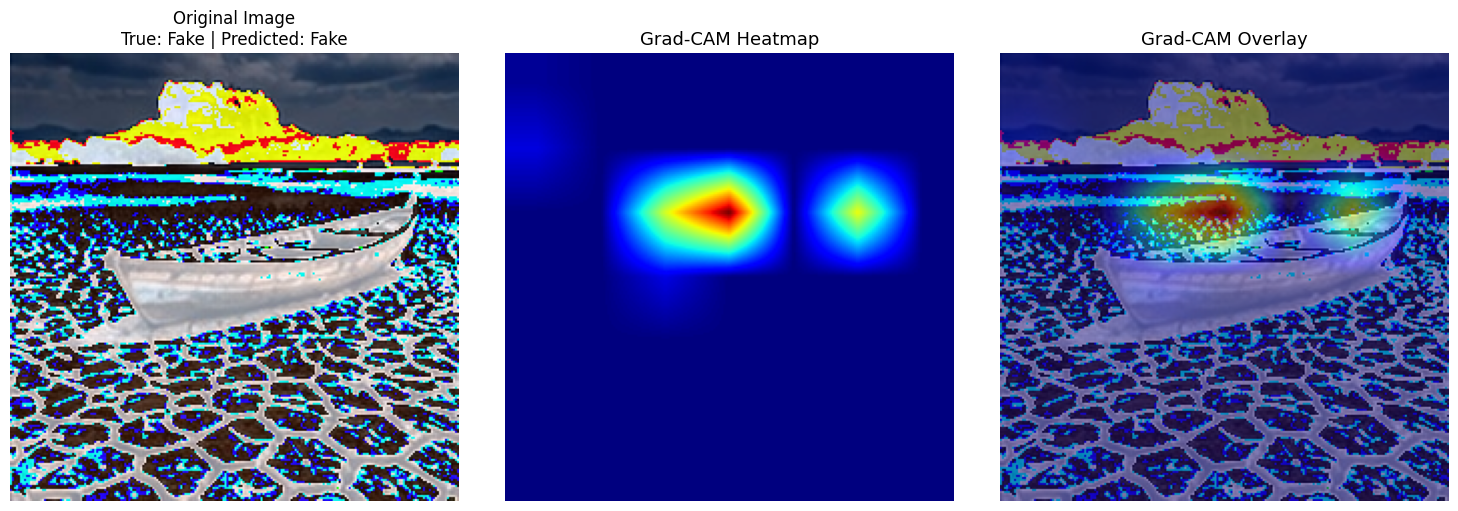

GRAD-CAM EXPLANATION SAVED

File:
/content/ResNet50_GradCAM_Explanation.png

Resolution: 300 DPI
✅ Grad-CAM figure saved successfully!


In [88]:
# ============================================================
# CELL 77 — SAVE GRAD-CAM EXPLANATION
# ============================================================

gradcam_path = "/content/ResNet50_GradCAM_Explanation.png"

plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)

plt.imshow(
    gradcam_image.astype(np.uint8)
)

plt.axis("off")

plt.title(
    f"Original Image\n"
    f"True: {label_names[true_label]} | "
    f"Predicted: {label_names[predicted_label]}",
    fontsize=12
)


# Heatmap
plt.subplot(1, 3, 2)

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.axis("off")

plt.title(
    "Grad-CAM Heatmap",
    fontsize=13
)


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(
    gradcam_image.astype(np.uint8)
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)

plt.axis("off")

plt.title(
    "Grad-CAM Overlay",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    gradcam_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("=" * 60)
print("GRAD-CAM EXPLANATION SAVED")
print("=" * 60)

print("\nFile:")
print(gradcam_path)

print("\nResolution: 300 DPI")
print("✅ Grad-CAM figure saved successfully!")

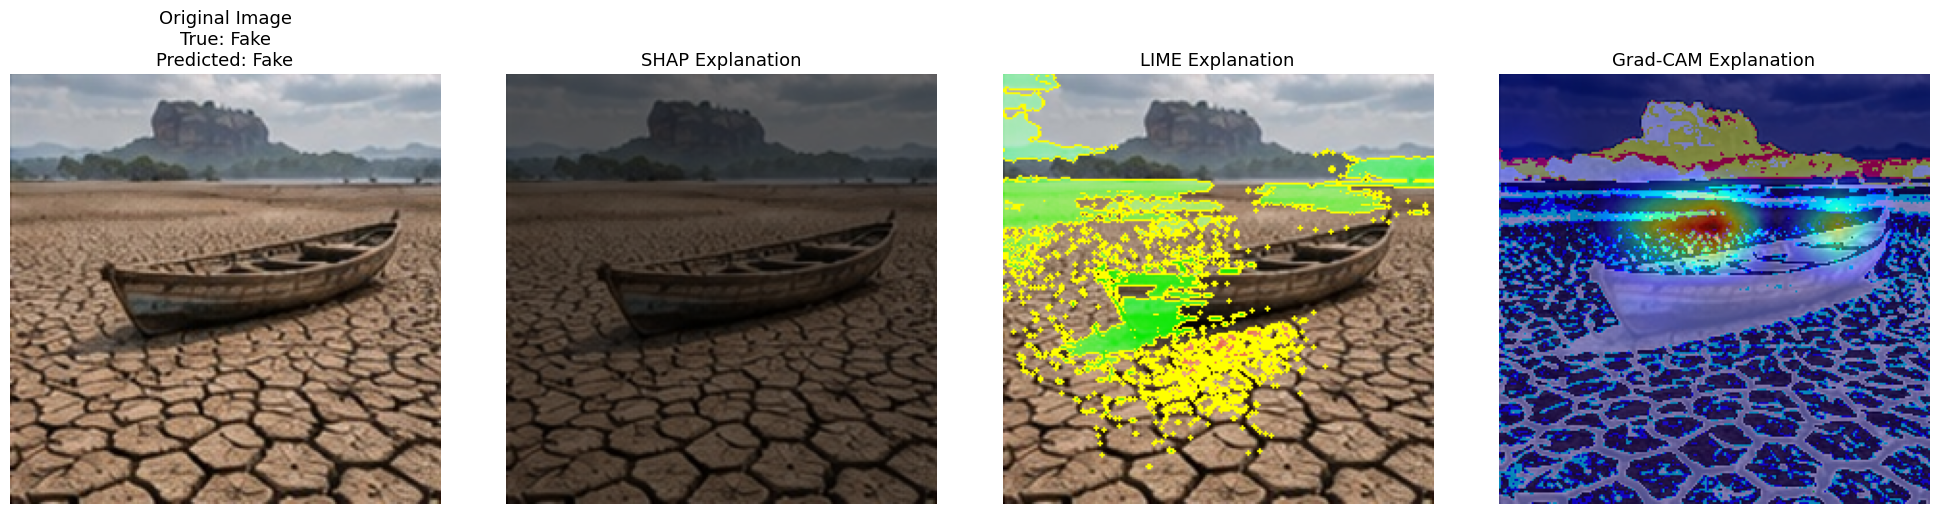

COMBINED EXPLAINABILITY FIGURE

Saved to:
/content/ResNet50_Explainability_Comparison.png

Methods:
1. Original Image
2. SHAP
3. LIME
4. Grad-CAM

Resolution: 300 DPI
✅ Explainability comparison completed!


In [89]:
# ============================================================
# CELL 78 — COMBINED EXPLAINABILITY FIGURE
# ============================================================

combined_path = "/content/ResNet50_Explainability_Comparison.png"

plt.figure(figsize=(20, 5))

# ------------------------------------------------------------
# 1. Original image
# ------------------------------------------------------------

plt.subplot(1, 4, 1)

plt.imshow(
    explain_image.resize((224, 224))
)

plt.axis("off")

plt.title(
    f"Original Image\n"
    f"True: {label_names[true_label]}\n"
    f"Predicted: {label_names[predicted_label]}",
    fontsize=13
)


# ------------------------------------------------------------
# 2. SHAP
# ------------------------------------------------------------

plt.subplot(1, 4, 2)

# SHAP values for the image
shap_values_array = shap_values.values[0]

# Sum SHAP values across RGB channels
shap_map = np.sum(
    shap_values_array,
    axis=-1
)

plt.imshow(
    explain_image.resize((224, 224))
)

plt.imshow(
    shap_map,
    cmap="seismic",
    alpha=0.55
)

plt.axis("off")

plt.title(
    "SHAP Explanation",
    fontsize=13
)


# ------------------------------------------------------------
# 3. LIME
# ------------------------------------------------------------

plt.subplot(1, 4, 3)

plt.imshow(
    mark_boundaries(
        lime_temp / 255.0,
        lime_mask
    )
)

plt.axis("off")

plt.title(
    "LIME Explanation",
    fontsize=13
)


# ------------------------------------------------------------
# 4. Grad-CAM
# ------------------------------------------------------------

plt.subplot(1, 4, 4)

plt.imshow(
    gradcam_image.astype(np.uint8)
)

plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45
)

plt.axis("off")

plt.title(
    "Grad-CAM Explanation",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    combined_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("COMBINED EXPLAINABILITY FIGURE")
print("=" * 60)

print("\nSaved to:")
print(combined_path)

print("\nMethods:")
print("1. Original Image")
print("2. SHAP")
print("3. LIME")
print("4. Grad-CAM")

print("\nResolution: 300 DPI")
print("✅ Explainability comparison completed!")

In [90]:
# ============================================================
# CELL 79 — FINAL EXPLAINABILITY SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("              RESNET50 EXPLAINABILITY SUMMARY")
print("=" * 75)

print("\nTEST IMAGE")
print("-" * 75)
print(f"Image             : {os.path.basename(image_path)}")
print(f"True Label        : {label_names[true_label]}")
print(f"Predicted Label   : {label_names[predicted_label]}")
print(f"Fake Probability  : {(1-prediction_probability)*100:.2f}%")
print(f"Real Probability  : {prediction_probability*100:.2f}%")

print("\nEXPLAINABILITY METHODS")
print("-" * 75)

print("SHAP")
print("  → Identifies image regions contributing to the model output.")
print("  → Saved: ResNet50_SHAP_Explanation.png")

print("\nLIME")
print("  → Identifies important local superpixel regions.")
print("  → Saved: ResNet50_LIME_Explanation.png")

print("\nGrad-CAM")
print("  → Highlights CNN feature regions important to the prediction.")
print("  → Saved: ResNet50_GradCAM_Explanation.png")

print("\nCOMBINED FIGURE")
print("  → Original + SHAP + LIME + Grad-CAM")
print("  → Saved: ResNet50_Explainability_Comparison.png")

print("\n" + "=" * 75)
print("EXPLAINABILITY PIPELINE COMPLETED")
print("=" * 75)


              RESNET50 EXPLAINABILITY SUMMARY

TEST IMAGE
---------------------------------------------------------------------------
Image             : test_Fake_0000.jpg
True Label        : Fake
Predicted Label   : Fake
Fake Probability  : 99.82%
Real Probability  : 0.18%

EXPLAINABILITY METHODS
---------------------------------------------------------------------------
SHAP
  → Identifies image regions contributing to the model output.
  → Saved: ResNet50_SHAP_Explanation.png

LIME
  → Identifies important local superpixel regions.
  → Saved: ResNet50_LIME_Explanation.png

Grad-CAM
  → Highlights CNN feature regions important to the prediction.
  → Saved: ResNet50_GradCAM_Explanation.png

COMBINED FIGURE
  → Original + SHAP + LIME + Grad-CAM
  → Saved: ResNet50_Explainability_Comparison.png

EXPLAINABILITY PIPELINE COMPLETED


Saving sri_lanka_fake_0442.jpg to sri_lanka_fake_0442.jpg


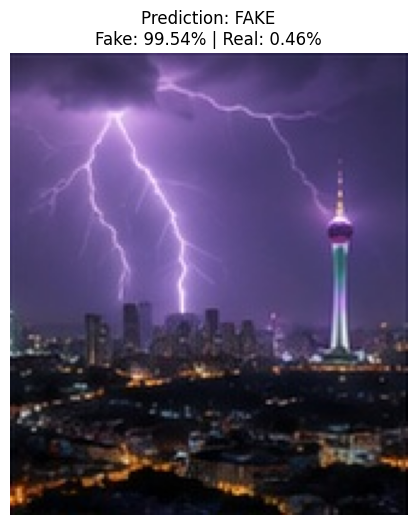

        RESNET50 NEW IMAGE PREDICTION
Image       : sri_lanka_fake_0442.jpg
Prediction  : FAKE
Fake        : 99.54%
Real        : 0.46%
Confidence  : 99.54%


In [91]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload a new image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Load image
img = Image.open(image_path).convert("RGB")

# Preprocess
img_resized = img.resize((224, 224))
img_array = np.array(img_resized, dtype=np.float32)

# ResNet50 preprocessing
img_array = preprocess_input(img_array)

# Add batch dimension
img_input = np.expand_dims(img_array, axis=0)

# Prediction
prob_real = float(final_model.predict(img_input, verbose=0)[0][0])
prob_fake = 1 - prob_real

# Class
if prob_real >= 0.5:
    prediction = "REAL"
    confidence = prob_real
else:
    prediction = "FAKE"
    confidence = prob_fake

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {prediction}\n"
    f"Fake: {prob_fake*100:.2f}% | Real: {prob_real*100:.2f}%"
)
plt.show()

print("=" * 50)
print("        RESNET50 NEW IMAGE PREDICTION")
print("=" * 50)
print(f"Image       : {image_path}")
print(f"Prediction  : {prediction}")
print(f"Fake        : {prob_fake*100:.2f}%")
print(f"Real        : {prob_real*100:.2f}%")
print(f"Confidence  : {confidence*100:.2f}%")
print("=" * 50)

Saving images (6).jpg to images (6).jpg


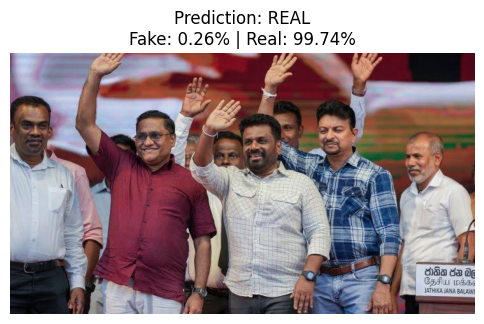

        RESNET50 NEW IMAGE PREDICTION
Image       : images (6).jpg
Prediction  : REAL
Fake        : 0.26%
Real        : 99.74%
Confidence  : 99.74%


In [92]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Upload a new image
uploaded = files.upload()

# Get uploaded filename
image_path = list(uploaded.keys())[0]

# Load image
img = Image.open(image_path).convert("RGB")

# Preprocess
img_resized = img.resize((224, 224))
img_array = np.array(img_resized, dtype=np.float32)

# ResNet50 preprocessing
img_array = preprocess_input(img_array)

# Add batch dimension
img_input = np.expand_dims(img_array, axis=0)

# Prediction
prob_real = float(final_model.predict(img_input, verbose=0)[0][0])
prob_fake = 1 - prob_real

# Class
if prob_real >= 0.5:
    prediction = "REAL"
    confidence = prob_real
else:
    prediction = "FAKE"
    confidence = prob_fake

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {prediction}\n"
    f"Fake: {prob_fake*100:.2f}% | Real: {prob_real*100:.2f}%"
)
plt.show()

print("=" * 50)
print("        RESNET50 NEW IMAGE PREDICTION")
print("=" * 50)
print(f"Image       : {image_path}")
print(f"Prediction  : {prediction}")
print(f"Fake        : {prob_fake*100:.2f}%")
print(f"Real        : {prob_real*100:.2f}%")
print(f"Confidence  : {confidence*100:.2f}%")
print("=" * 50)

Saving sri_lanka_fake_0442.jpg to sri_lanka_fake_0442 (2).jpg
             NEW IMAGE PREDICTION
Image       : sri_lanka_fake_0442 (2).jpg
Prediction  : FAKE
Fake        : 99.54%
Real        : 0.46%
Confidence  : 99.54%

Backbone: resnet50
Last convolutional layer: conv5_block3_out
Layer output shape: (None, 7, 7, 2048)


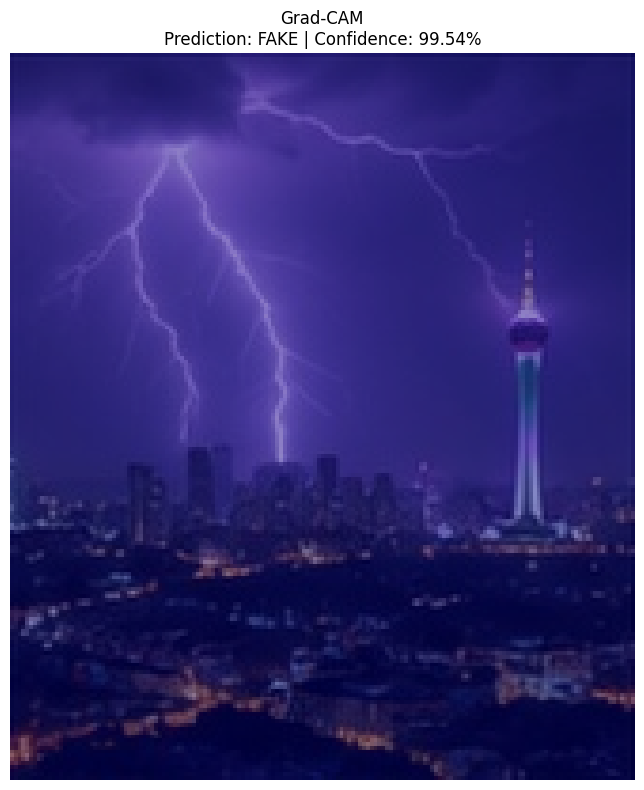


Grad-CAM completed successfully.

Generating SHAP explanation...


  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:18, 18.79s/it]               


SHAP completed successfully.

Generating LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

LIME completed successfully.


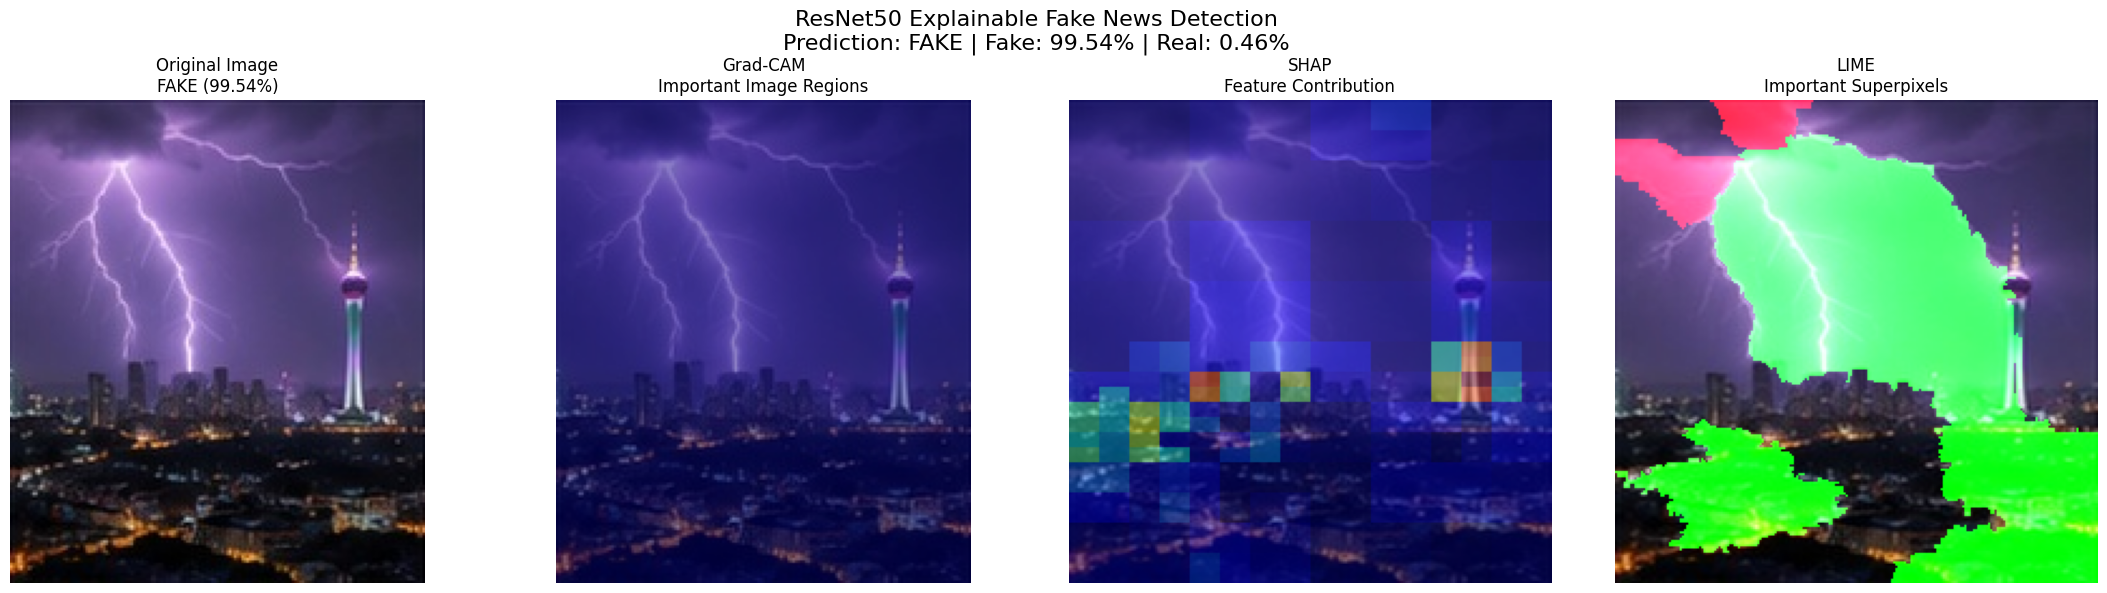



             FINAL RESULT
Image       : sri_lanka_fake_0442 (2).jpg
Prediction  : FAKE
Fake        : 99.54%
Real        : 0.46%
Confidence  : 99.54%

Explainability:
✓ Grad-CAM
✓ SHAP
✓ LIME

Saved file:
/content/ResNet50_New_Image_Explainability.png


In [98]:
# ============================================================
# RESNET50 - NEW IMAGE PREDICTION + EXPLAINABILITY
# CORRECTED VERSION
# ============================================================

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import shap
from lime import lime_image

# ============================================================
# 1. UPLOAD NEW IMAGE
# ============================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

original_img = Image.open(image_path).convert("RGB")

# ============================================================
# 2. PREPROCESS IMAGE
# ============================================================

img_resized = original_img.resize((224, 224))

img_array = np.array(
    img_resized,
    dtype=np.float32
)

img_preprocessed = preprocess_input(
    img_array.copy()
)

img_input = np.expand_dims(
    img_preprocessed,
    axis=0
)

# ============================================================
# 3. PREDICTION
# ============================================================

prob_real = float(
    final_model.predict(
        img_input,
        verbose=0
    )[0][0]
)

prob_fake = 1.0 - prob_real

if prob_real >= 0.5:
    prediction = "REAL"
    confidence = prob_real
else:
    prediction = "FAKE"
    confidence = prob_fake

print("=" * 60)
print("             NEW IMAGE PREDICTION")
print("=" * 60)
print(f"Image       : {image_path}")
print(f"Prediction  : {prediction}")
print(f"Fake        : {prob_fake * 100:.2f}%")
print(f"Real        : {prob_real * 100:.2f}%")
print(f"Confidence  : {confidence * 100:.2f}%")
print("=" * 60)

# ============================================================
# 4. FIND RESNET50 BACKBONE
# ============================================================

backbone = None

for layer in final_model.layers:

    if isinstance(layer, tf.keras.Model):

        if "resnet50" in layer.name.lower():

            backbone = layer
            break

if backbone is None:
    raise ValueError(
        "ResNet50 backbone was not found."
    )

print("\nBackbone:", backbone.name)

# ============================================================
# 5. FIND LAST CONVOLUTIONAL LAYER
# ============================================================

last_conv_layer = None

for layer in reversed(backbone.layers):

    try:

        output_shape = layer.output.shape

        if len(output_shape) == 4:

            last_conv_layer = layer
            break

    except:
        continue

if last_conv_layer is None:
    raise ValueError(
        "Last convolutional layer was not found."
    )

print(
    "Last convolutional layer:",
    last_conv_layer.name
)

print(
    "Layer output shape:",
    last_conv_layer.output.shape
)

# ============================================================
# 6. GRAD-CAM
# ============================================================

grad_model = tf.keras.models.Model(
    inputs=backbone.input,
    outputs=[
        last_conv_layer.output,
        backbone.output
    ]
)

with tf.GradientTape() as tape:

    conv_outputs, backbone_features = grad_model(
        img_input
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # 7x7x2048 -> Global Average Pooling -> 2048
    # --------------------------------------------------------

    x = tf.reduce_mean(
        backbone_features,
        axis=(1, 2)
    )

    # --------------------------------------------------------
    # Find BatchNormalization layer
    # --------------------------------------------------------

    bn_layer = None

    for layer in final_model.layers:

        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):

            bn_layer = layer
            break

    if bn_layer is not None:

        x = bn_layer(
            x,
            training=False
        )

    # --------------------------------------------------------
    # Find Dense layers
    # --------------------------------------------------------

    dense_layers = [
        layer
        for layer in final_model.layers
        if isinstance(
            layer,
            tf.keras.layers.Dense
        )
    ]

    if len(dense_layers) < 2:

        raise ValueError(
            "Expected two Dense layers."
        )

    # First Dense layer
    x = dense_layers[0](x)

    # Final sigmoid Dense layer
    prediction_output = dense_layers[-1](x)

    target = prediction_output[:, 0]

# ============================================================
# 7. CALCULATE GRADIENTS
# ============================================================

grads = tape.gradient(
    target,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(1, 2)
)

conv_outputs = conv_outputs[0]

pooled_grads = pooled_grads[0]

# ============================================================
# 8. CREATE GRAD-CAM HEATMAP
# ============================================================

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = tf.maximum(
    heatmap,
    0
)

heatmap = heatmap / tf.maximum(
    tf.reduce_max(heatmap),
    1e-8
)

heatmap = heatmap.numpy()

# Resize heatmap
heatmap_resized = tf.image.resize(
    heatmap[..., np.newaxis],
    (
        original_img.height,
        original_img.width
    )
).numpy().squeeze()

# ============================================================
# 9. SHOW GRAD-CAM
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(original_img)

plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

plt.axis("off")

plt.title(
    f"Grad-CAM\n"
    f"Prediction: {prediction} | "
    f"Confidence: {confidence * 100:.2f}%"
)

plt.tight_layout()

plt.show()

print("\nGrad-CAM completed successfully.")

# ============================================================
# 10. SHAP
# ============================================================

def shap_predict(images):

    images = np.array(
        images,
        dtype=np.float32
    )

    processed = preprocess_input(
        images.copy()
    )

    return final_model.predict(
        processed,
        verbose=0
    )


print("\nGenerating SHAP explanation...")

masker = shap.maskers.Image(
    "blur(32,32)",
    (224, 224, 3)
)

shap_explainer = shap.Explainer(
    shap_predict,
    masker
)

shap_image = np.array(
    original_img.resize((224, 224)),
    dtype=np.float32
)

shap_values = shap_explainer(
    shap_image[np.newaxis, ...],
    max_evals=1000,
    outputs=shap.Explanation.argsort.flip[:1]
)

print("SHAP completed successfully.")

# ============================================================
# 11. LIME
# ============================================================

def lime_predict(images):

    images = np.array(
        images,
        dtype=np.float32
    )

    processed = preprocess_input(
        images.copy()
    )

    real_probs = final_model.predict(
        processed,
        verbose=0
    ).reshape(-1)

    fake_probs = 1.0 - real_probs

    # Column 0 = Fake
    # Column 1 = Real

    return np.column_stack(
        [fake_probs, real_probs]
    )


print("\nGenerating LIME explanation...")

lime_explainer = lime_image.LimeImageExplainer(
    random_state=SEED
)

lime_explanation = lime_explainer.explain_instance(
    shap_image.astype(np.uint8),
    lime_predict,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

if prediction == "FAKE":
    lime_class = 0
else:
    lime_class = 1

lime_result, lime_mask = (
    lime_explanation.get_image_and_mask(
        lime_class,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )
)

print("LIME completed successfully.")

# ============================================================
# 12. FINAL EXPLAINABILITY FIGURE
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(22, 6)
)

# ------------------------------------------------------------
# Original
# ------------------------------------------------------------

axes[0].imshow(
    original_img
)

axes[0].set_title(
    f"Original Image\n"
    f"{prediction} ({confidence*100:.2f}%)"
)

axes[0].axis("off")

# ------------------------------------------------------------
# Grad-CAM
# ------------------------------------------------------------

axes[1].imshow(
    original_img
)

axes[1].imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.45
)

axes[1].set_title(
    "Grad-CAM\nImportant Image Regions"
)

axes[1].axis("off")

# ------------------------------------------------------------
# SHAP
# ------------------------------------------------------------

axes[2].imshow(
    shap_image.astype(np.uint8)
)

try:

    shap_array = shap_values.values[0]

    if shap_array.ndim == 4:
        shap_array = shap_array[..., 0]

    if shap_array.ndim == 3:
        shap_array = np.mean(
            np.abs(shap_array),
            axis=-1
        )

    axes[2].imshow(
        shap_array,
        cmap="jet",
        alpha=0.45
    )

except Exception as e:

    print(
        "SHAP visualization warning:",
        e
    )

axes[2].set_title(
    "SHAP\nFeature Contribution"
)

axes[2].axis("off")

# ------------------------------------------------------------
# LIME
# ------------------------------------------------------------

axes[3].imshow(
    lime_result
)

axes[3].set_title(
    "LIME\nImportant Superpixels"
)

axes[3].axis("off")

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

plt.suptitle(
    f"ResNet50 Explainable Fake News Detection\n"
    f"Prediction: {prediction} | "
    f"Fake: {prob_fake*100:.2f}% | "
    f"Real: {prob_real*100:.2f}%",
    fontsize=16
)

plt.tight_layout()

plt.show()

# ============================================================
# 13. SAVE FINAL EXPLANATION
# ============================================================

output_path = (
    "/content/"
    "ResNet50_New_Image_Explainability.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("             FINAL RESULT")
print("=" * 60)

print(f"Image       : {image_path}")
print(f"Prediction  : {prediction}")
print(f"Fake        : {prob_fake*100:.2f}%")
print(f"Real        : {prob_real*100:.2f}%")
print(f"Confidence  : {confidence*100:.2f}%")

print("\nExplainability:")
print("✓ Grad-CAM")
print("✓ SHAP")
print("✓ LIME")

print("\nSaved file:")
print(output_path)

print("=" * 60)

In [99]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=["Fake", "Real"],
    digits=4
)

print("=" * 60)
print("          RESNET50 CLASSIFICATION REPORT")
print("=" * 60)
print(report)
print("=" * 60)

          RESNET50 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fake     0.9091    0.9333    0.9211        75
        Real     0.9306    0.9054    0.9178        74

    accuracy                         0.9195       149
   macro avg     0.9198    0.9194    0.9194       149
weighted avg     0.9198    0.9195    0.9194       149



In [100]:
# Save trained ResNet50 model
MODEL_PATH = "/content/ResNet50_FakeNews_Final.keras"

final_model.save(MODEL_PATH)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
/content/ResNet50_FakeNews_Final.keras


In [101]:
from google.colab import files

files.download("/content/ResNet50_FakeNews_Final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>